# ICMS 150 (April 4)

- **Combined_Pattern_Registrations.pkl**: including electrical stimulation pattern informations, the same format as the one I shared before with you.
- **All_Shank_Spk_Vecs.npy**: spiking events from each neuron. The same format as previous. Sampling frequency: 30K
- **VStim_Onset_TS.npy**: the onset timestamps of each visual stimulus trials. NOTE: These are recorded at a different sampling frequency, which is 1K. DO REMEMBER to align data in 2. and 3., they're not written under the same clock (due to hardware setup).
- **VStim_Labels.npy**: the orientation degree for each visual stimulus trials. Each degree should have 100 trials.


Visual stim duration: 0.5s ON, 0.5s OFF
Velocity(temporal frequency): 3Hz
Width (spatial frequency): 0.05 cycle/degree
After that is 4000 patterns, 3000 samples appear 1 times, 100 oracle samples repeating 10 times


In [21]:
import sys
sys.path.insert(0, '/Users/shubhom/Documents/closed_loop_stim/patterns_5k')

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from utils import read_pattern_json, preprocess_pattern_stimulations_df
%load_ext autoreload
%autoreload 2


all_spikes = np.load("data/All_Shank_Spk_Vecs.npy", allow_pickle=False) # contains each spike indexed with (sample index, unit index, segment index)
spikes_df = pd.DataFrame(all_spikes)  # columns auto-named from dtype fields
spikes_df.rename(columns={'sample_index': 'timestamp', 'unit_index': 'neuron_id'}, inplace=True)
spikes_df.drop(columns=['segment_index'], inplace=True)

pattern_df, min_pattern_timestamp = preprocess_pattern_stimulations_df(read_pattern_json("data/Combined_Pattern_Registrations.pkl"), align_to_stim=True)
pattern_df = pattern_df.drop_duplicates()

visual_stim_times = np.load("data/VStim_Onset_TS.npy") * 30 # 1600
visual_stim_labels = np.load("data/VStim_Labels.npy") # 1600 

visual_orientation_degs = np.sort(np.unique(visual_stim_labels))
visual_trial_df = pd.DataFrame({
    'timestamp': visual_stim_times,
    'orientation': visual_stim_labels
})
min_visual_timestamp = visual_trial_df['timestamp'].min()
max_visual_timestamp = visual_trial_df['timestamp'].max()

visual_spikes = spikes_df[(spikes_df['timestamp'] >= min_visual_timestamp) & (spikes_df['timestamp'] <= max_visual_timestamp)].copy()



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [22]:

# --- Timing constants -------------------------------------------------
# Spike timestamps are in *samples* at SAMPLE_RATE Hz. The visual stimulus
# was shown for STIM_MS ms, so we bin the full stim window (no data is
# thrown away). The window is chopped into bins of BIN_MS ms.
SAMPLE_RATE    = 30_000                       # Hz
STIM_MS        = 500                          # stimulus duration (ms)
BIN_MS         = 10                           # PSTH bin width (ms)

SAMPLES_PER_MS = SAMPLE_RATE // 1000          # 30 samples / ms
WINDOW_LEN     = STIM_MS * SAMPLES_PER_MS     # 500 ms -> 15000 samples
BIN_SAMPLES    = BIN_MS  * SAMPLES_PER_MS     # 50 ms  -> 1500 samples
N_BINS         = WINDOW_LEN // BIN_SAMPLES    # STIM_MS / BIN_MS
assert WINDOW_LEN % BIN_SAMPLES == 0, "BIN_MS must evenly divide STIM_MS"

N_VIS_TRIALS = 100

all_neuron_ids = np.sort(visual_spikes['neuron_id'].unique())
n_neurons = len(all_neuron_ids)
neuron_to_idx = {n: i for i, n in enumerate(all_neuron_ids)}

sum_responses = []
for orientation in visual_orientation_degs:
    sum_response = np.zeros((n_neurons, N_BINS))
    for trial in range(N_VIS_TRIALS):
        trial_time = visual_trial_df[visual_trial_df['orientation'] == orientation].iloc[trial]['timestamp']
        trial_spikes = visual_spikes[(visual_spikes['timestamp'] >= trial_time) &
                                     (visual_spikes['timestamp'] <  trial_time + WINDOW_LEN)]
        if trial_spikes.empty:
            continue
        bin_edges = trial_time + np.arange(N_BINS + 1) * BIN_SAMPLES  # N_BINS+1 edges across STIM_MS

        for neuron_id in trial_spikes['neuron_id'].unique():
            idx = neuron_to_idx[neuron_id]
            counts, _ = np.histogram(
                trial_spikes[trial_spikes['neuron_id'] == neuron_id]['timestamp'],
                bins=bin_edges,
            )
            sum_response[idx] += counts
    sum_response /= N_VIS_TRIALS  # average over trials 
    sum_responses.append(sum_response) 
sum_responses = np.array(sum_responses)       # (n_orientations, n_neurons, N_BINS)
print (sum_responses.shape)
print(f"Window: {STIM_MS} ms = {WINDOW_LEN} samples at {SAMPLE_RATE} Hz")
print(f"Bins:   {N_BINS} x {BIN_MS} ms ({BIN_SAMPLES} samples each)")
print(f"sum_responses shape (orient, neuron, time_bin): {sum_responses.shape}")


(16, 72, 50)
Window: 500 ms = 15000 samples at 30000 Hz
Bins:   50 x 10 ms (300 samples each)
sum_responses shape (orient, neuron, time_bin): (16, 72, 50)


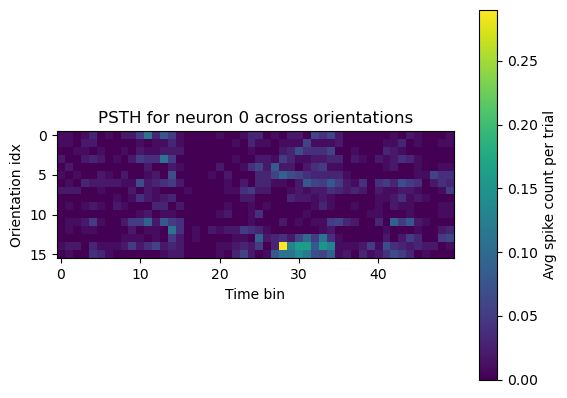

In [23]:
plt.imshow(sum_responses[:, 3, :])
plt.ylabel("Orientation idx")
plt.xlabel("Time bin")
plt.title("PSTH for neuron 0 across orientations")
plt.colorbar(label="Avg spike count per trial")
plt.show()

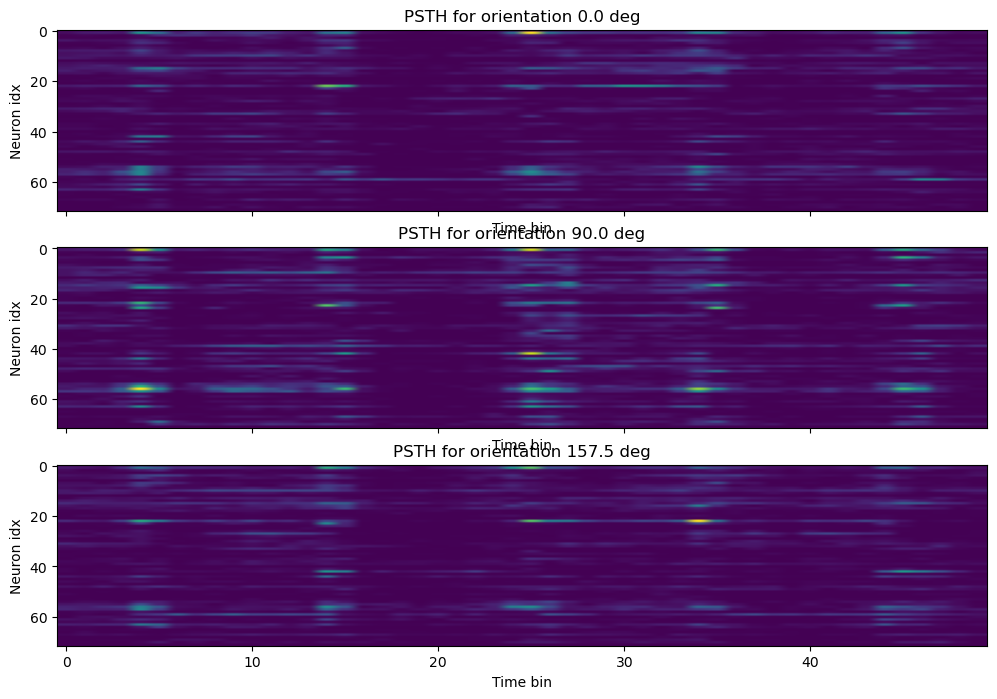

In [24]:
f, ax = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
ax[0].imshow(sum_responses[0], aspect='auto')
ax[0].set_xlabel("Time bin")
ax[0].set_ylabel("Neuron idx")
ax[0].set_title(f"PSTH for orientation {visual_orientation_degs[0]} deg")

ax[1].imshow(sum_responses[4], aspect='auto')
ax[1].set_xlabel("Time bin")
ax[1].set_ylabel("Neuron idx")
ax[1].set_title(f"PSTH for orientation {visual_orientation_degs[4]} deg")

ax[2].imshow(sum_responses[7], aspect='auto')
ax[2].set_xlabel("Time bin")
ax[2].set_ylabel("Neuron idx")
ax[2].set_title(f"PSTH for orientation {visual_orientation_degs[7]} deg")
plt.show()

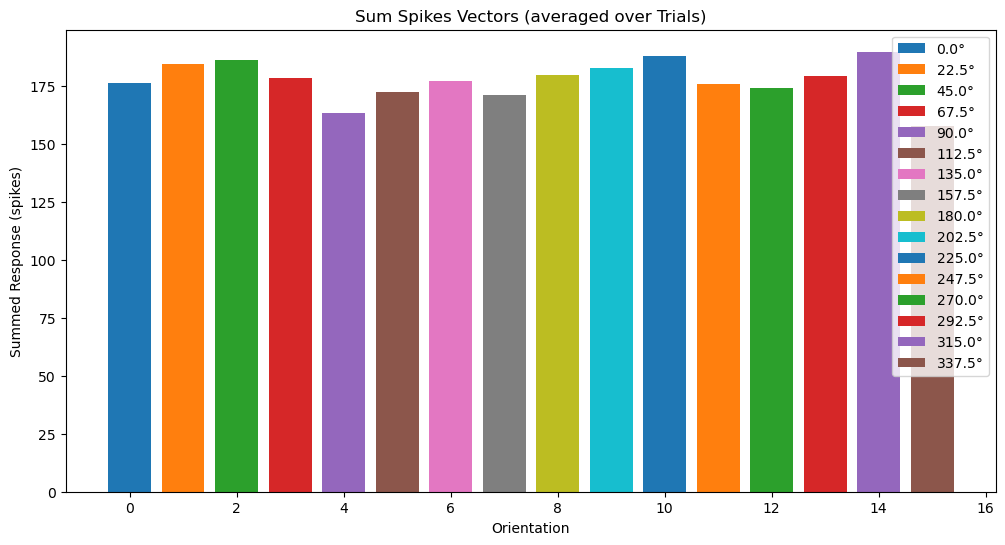

In [25]:
# Plot orientation response vectors
plt.figure(figsize=(12, 6))
for i, orientation in enumerate(visual_orientation_degs):
    plt.bar(i, sum_responses[i].sum(), label=f'{orientation}°')
plt.xlabel('Orientation')
plt.ylabel('Summed Response (spikes)')
plt.title('Sum Spikes Vectors (averaged over Trials)')
plt.legend()
plt.show()

In [26]:
import plotly.graph_objects as go
from sklearn.decomposition import PCA
# Compute 3-axis projection: [CIS, PC1, PC2]
X = sum_responses.sum(axis=-1) # (n_orientations, n_neurons)
mean_vec = X.mean(axis=0, keepdims=True)  # (1, n_neurons)

pca3 = PCA(n_components=2)
pca3.fit(X)

proj, _ = np.linalg.qr(np.array([
    mean_vec[0],
    pca3.components_[0],
    pca3.components_[1],
]).T)  # (n_neurons, 3)

coords = X @ proj  # (n_orientations, 3)

colors = [f'hsl({int(o)}, 80%, 50%)' for o in visual_orientation_degs]


# map orientations to 0-360 by doubling (so 0=180 both map to 0/360)
doubled = (np.array(visual_orientation_degs) * 2) % 360


fig = go.Figure()
fig.add_trace(go.Scatter3d(
    x=coords[:, 0], y=coords[:, 1], z=coords[:, 2],
    mode='markers+text',
    marker=dict(size=8, color=doubled, colorscale='HSV',
                cmin=0, cmax=360,
                colorbar=dict(
                    title='Orientation (°)',
                    tickvals=np.arange(0, 361, 72),
                    ticktext=[f'{int(v/2)}°' for v in np.arange(0, 361, 72)],
                ),
                line=dict(color='black', width=1)),
    text=[f'{int(o)}°' for o in visual_orientation_degs],
    textposition='top center',
))

fig.update_layout(
    title='Average Neural Responses to Visual Stimuli',
    scene=dict(xaxis_title='CIS', yaxis_title='PC1', zaxis_title='PC2',
               aspectmode='data'),
    width=800, height=700,
)
fig.show()


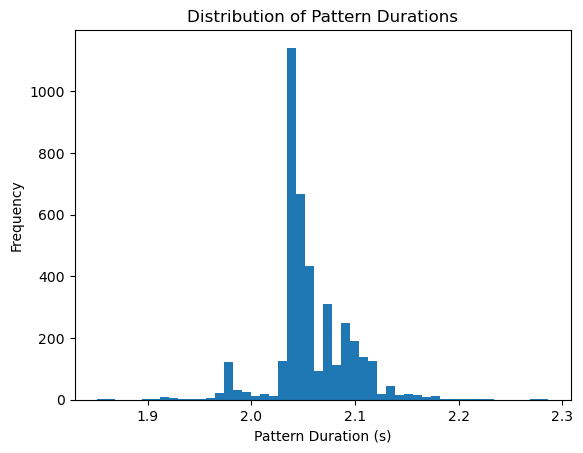

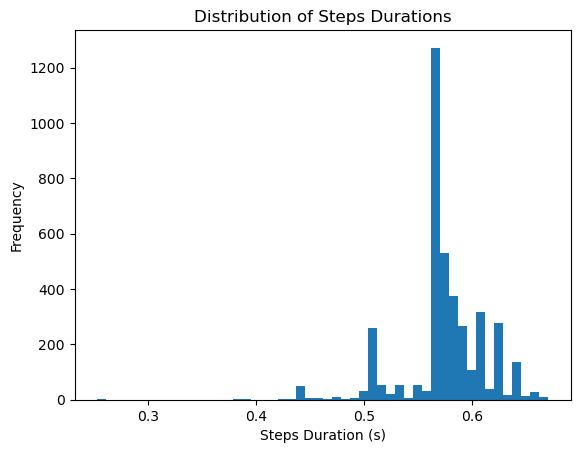

In [27]:
pattern_durations = pattern_df.groupby('pattern_timing_index')['pattern_duration'].first()
plt.hist(pattern_durations / 30000, bins=50)
plt.xlabel('Pattern Duration (s)')
plt.ylabel('Frequency')
plt.title('Distribution of Pattern Durations')
plt.show()



pattern_durations = pattern_df.groupby('pattern_timing_index')['step_start_timestamp'].agg(['min', 'max'])
pattern_durations['steps_duration'] = pattern_durations['max'] - pattern_durations['min']
plt.hist(pattern_durations['steps_duration'] / 30000, bins=50)
plt.xlabel('Steps Duration (s)')
plt.ylabel('Frequency')
plt.title('Distribution of Steps Durations')
plt.show()


In [28]:

import os, sys
sys.path.insert(0, '/Users/shubhom/Documents/closed_loop_stim/patterns_5k')
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from viz import plot_stimulation_polarity_timeseries, plot_oracle_pattern_average_responses

VIZ_DIR = 'results/visual_resposne_ICMS150_4_6/viz'
os.makedirs('results', exist_ok=True)


# sample_pattern_names = list(pattern_df['pattern_name'].unique())
# for pname in sample_pattern_names:
#     plot_stimulation_polarity_timeseries(
#         pattern_stims, pattern_polarities, pname,
#         savepath=os.path.join(VIZ_DIR, 'stim_patterns')
#     )
# print(f"Saved {len(sample_pattern_names)} stim pattern plots → {VIZ_DIR}/stim_patterns/")


In [29]:
import sys
sys.path.insert(0, '/Users/shubhom/Documents/closed_loop_stim/patterns_5k')
import os 

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from utils import (read_pattern_json, preprocess_pattern_stimulations_df,
                   trial_breakout_spikes_and_patterns, BinnedStimSpikeDataset,
                   NUM_STIM_LEVELS)
from models import SimpleCausalSpikeCNN, train_epoch, validate

# --- Load pattern data (same pipeline as patterns_5k) ---
DATADIR = 'data'
pattern_df_raw = read_pattern_json(f'{DATADIR}/Combined_Pattern_Registrations.pkl')
pattern_df, _ = preprocess_pattern_stimulations_df(pattern_df_raw, align_to_stim=True)

# Use the same spikes_df already loaded above
channel_to_index = {ch: idx for idx, ch in enumerate(sorted(pattern_df['channel'].dropna().unique()))}
spiking_neurons = np.sort(spikes_df['neuron_id'].unique())
spiking_neuron_to_index = {n: i for i, n in enumerate(spiking_neurons)}
n_neurons = len(spiking_neurons)
n_stim_channels = len(channel_to_index)
print(f"Stim channels: {n_stim_channels}, Neurons: {n_neurons}")


# --- Config (matching patterns_5k/config.yaml) ---
INPUT_BIN_MS   = 10
OUTPUT_BIN_MS  = 10
N_INPUT_BINS   = 80
N_OUTPUT_BINS  = 80
MAX_TIME_MS    = 800
OUTPUT_OFFSET  = 0
ENCODING_MODE  = 'current'
BATCH_SIZE     = 16
SEED = 42
np.random.seed(SEED)

pattern_stims, pattern_polarities, spike_responses, timing_to_pattern, unique_trials = (
    trial_breakout_spikes_and_patterns(
        spikes_df, pattern_df, channel_to_index,
        spiking_neurons=spiking_neurons,
        spiking_neuron_to_index=spiking_neuron_to_index,
        stim_time_ms=MAX_TIME_MS,
    )
)
print(f"Unique patterns: {len(pattern_stims)}, Total trials: {len(spike_responses)}")


# --- Train/val/test split: oracle patterns as test ---
unique_trials_info = pattern_df[['pattern_timing_index','pattern_name','is_oracle']].drop_duplicates()
oracle_timing    = unique_trials_info[unique_trials_info['is_oracle']]['pattern_timing_index'].tolist()
non_oracle_timing = unique_trials_info[~unique_trials_info['is_oracle']]['pattern_timing_index'].tolist()
np.random.shuffle(non_oracle_timing)
split = int(0.9 * len(non_oracle_timing))
train_indices = non_oracle_timing[:split]
val_indices   = non_oracle_timing[split:]
test_indices  = oracle_timing
print(f"Train: {len(train_indices)}, Val: {len(val_indices)}, Test: {len(test_indices)}")


Stim channels: 40, Neurons: 72
Unique patterns: 3100, Total trials: 4000
Train: 2700, Val: 300, Test: 1000


## Raster plots of neural response to stim

In [30]:

# ── 2. Spike rasters per trial ──────────────────────────────────────────
RASTER_BIN_MS  = 5    # bin size for smoothed rate
RASTER_WIN_MS  = 600   # window shown
VIZ_DIR = 'results/visual_resposne_ICMS150_4_6/viz'
raster_dir = os.path.join(VIZ_DIR, 'rasters')
os.makedirs(raster_dir, exist_ok=True)


for timing_idx in list(spike_responses.keys())[:30]:
    spk   = spike_responses[timing_idx]   # (n_neurons, 2000) at 1ms
    pname = timing_to_pattern[timing_idx]
    win   = spk[:, :RASTER_WIN_MS]        # (n_neurons, 600)
    stim  = pattern_stims[pname]          # (n_channels, 600)
    pol   = pattern_polarities[pname]     # (n_channels, 600), ±1

    # signed stim: +3 anodic, -3 cathodic
    signed_stim = stim * pol              # (n_channels, 600)

    fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True,
                             gridspec_kw={'height_ratios': [3, 2, 1]})

    # ── Raster ──────────────────────────────────────────────────────────
    ax = axes[0]
    for nidx in range(win.shape[0]):
        times = np.where(win[nidx] > 0)[0]
        ax.vlines(times, nidx - 0.4, nidx + 0.4, lw=0.8, color='k')
    ax.set_ylabel('Neuron')
    ax.set_title(f'Pattern {pname}  (timing_idx={timing_idx})')
    ax.set_ylim(-0.5, win.shape[0] - 0.5)

    # ── Stim overlay (channel × time heatmap) ───────────────────────────
    ax2 = axes[1]
    im = ax2.imshow(signed_stim, aspect='auto', interpolation='nearest',
                    cmap='RdBu_r', vmin=-3, vmax=3,
                    extent=[0, RASTER_WIN_MS, stim.shape[0], 0])
    plt.colorbar(im, ax=ax2, label='Current (a.u.)', fraction=0.02, pad=0.01)
    ax2.set_ylabel('Stim channel')

    # ── Population PSTH ─────────────────────────────────────────────────
    ax3 = axes[2]
    n_bins = RASTER_WIN_MS // RASTER_BIN_MS
    psth = win[:, :n_bins * RASTER_BIN_MS].reshape(win.shape[0], n_bins, RASTER_BIN_MS).sum(axis=(0, 2))
    ax3.bar(np.arange(n_bins) * RASTER_BIN_MS, psth, width=RASTER_BIN_MS,
            color='steelblue', align='edge')
    ax3.set_xlabel('Time (ms)')
    ax3.set_ylabel('Pop. spikes')

    plt.tight_layout()
    fig.savefig(os.path.join(raster_dir, f'raster_tidx{timing_idx}_p{pname}.png'), dpi=100)
    plt.close(fig)

print(f"Saved 30 rasters → {raster_dir}/")


Saved 30 rasters → results/visual_resposne_ICMS150_4_6/viz/rasters/


## Model the electrical stimulation response using TCN

In [34]:
KERNEL_SIZE = [5, 3] # bin_size


device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
model = SimpleCausalSpikeCNN(
    n_stim_channels=n_stim_channels + n_neurons,
    n_neurons=n_neurons,
    n_input_bins=N_INPUT_BINS ,  # extra bins for valid conv
    n_output_bins=N_OUTPUT_BINS,
    embedding_dim=0,
    conv_channels=[256, 128],
    kernel_sizes=KERNEL_SIZE,
    fc_dims=[256],
    dropout=0.2,
    num_stim_levels=NUM_STIM_LEVELS,
    use_init_state=True,                           # valid conv mode
).to(device)

dataset_kwargs = dict(
    pattern_df=pattern_df,
    spike_responses=spike_responses,
    channel_to_index=channel_to_index,
    timing_to_pattern=timing_to_pattern,
    encoding_mode=ENCODING_MODE,
    input_bin_size_ms=INPUT_BIN_MS,
    output_bin_size_ms=OUTPUT_BIN_MS,
    n_input_bins=N_INPUT_BINS,
    n_output_bins=N_OUTPUT_BINS,
    n_initial_state_bins=sum([KERNEL_SIZE - 1] if isinstance(KERNEL_SIZE, int) else [k - 1 for k in KERNEL_SIZE]),
    max_time_ms=MAX_TIME_MS,
    output_offset=OUTPUT_OFFSET,
    history=1, 
    init_state=True
)
train_ds = BinnedStimSpikeDataset(trial_indices=train_indices, **dataset_kwargs)
val_ds   = BinnedStimSpikeDataset(trial_indices=val_indices,   **dataset_kwargs)
test_ds  = BinnedStimSpikeDataset(trial_indices=test_indices,  **dataset_kwargs)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)



876 trials were added in spike responses for initial state that were not in the specified trial_indices
273 trials were added in spike responses for initial state that were not in the specified trial_indices
734 trials were added in spike responses for initial state that were not in the specified trial_indices


In [ ]:


criterion = nn.PoissonNLLLoss(log_input=True, reduction='none', full=True)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

# # --- Training ---
best_val, patience_count, PATIENCE = np.inf, 0, 10
for epoch in range(50):
    tr_loss = train_epoch(model, train_loader, criterion, optimizer, device, weight_loss=1)
    vl_loss, vl_corr = validate(model, val_loader, criterion, device, weight_loss=1)
    print(f"Epoch {epoch+1:3d} | train={tr_loss:.4f}  val={vl_loss:.4f}  corr={vl_corr:.4f}")
    if vl_loss < best_val:
        best_val = vl_loss
        patience_count = 0
        torch.save(model.state_dict(), f'{datetime.datetime.now().date().strftime("%Y-%m-%d")}_vis_stim_icms_model.pt')
    else:
        patience_count += 1
        if patience_count >= PATIENCE:
            print("Early stopping.")
            break
print ("Model saved at ", f'{datetime.datetime.now().date().strftime("%Y-%m-%d")}_vis_stim_icms_model.pt')

Epoch   1 | train=0.2375  val=0.1975  corr=0.1961


Epoch   2 | train=0.1960  val=0.1897  corr=0.2451


Epoch   3 | train=0.1905  val=0.1852  corr=0.2679


Epoch   4 | train=0.1876  val=0.1833  corr=0.2804


Epoch   5 | train=0.1858  val=0.1829  corr=0.2876


...

Epoch  46 | train=0.1783  val=0.1758  corr=0.3233


Epoch  47 | train=0.1784  val=0.1759  corr=0.3247


Epoch  48 | train=0.1783  val=0.1759  corr=0.3250


Epoch  49 | train=0.1783  val=0.1760  corr=0.3247


Epoch  50 | train=0.1783  val=0.1758  corr=0.3246
Model saved at  2026-04-22_vis_stim_icms_model.pt


In [24]:
# model.load_state_dict(torch.load(f'{datetime.datetime.now().date().strftime("%Y-%m-%d")}_vis_stim_icms_model.pt'))

device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
model = SimpleCausalSpikeCNN(
    n_stim_channels=n_stim_channels + n_neurons,
    n_neurons=n_neurons,
    n_input_bins=N_INPUT_BINS ,  # extra bins for valid conv
    n_output_bins=N_OUTPUT_BINS,
    embedding_dim=0,
    conv_channels=[128, 256],
    kernel_sizes=[3, 5],
    fc_dims=[256],
    dropout=0.2,
    num_stim_levels=NUM_STIM_LEVELS,
    use_init_state=True,                           # valid conv mode
).to(device)
model.load_state_dict(torch.load('2026-04-22_vis_stim_icms_model.pt'))

<All keys matched successfully>

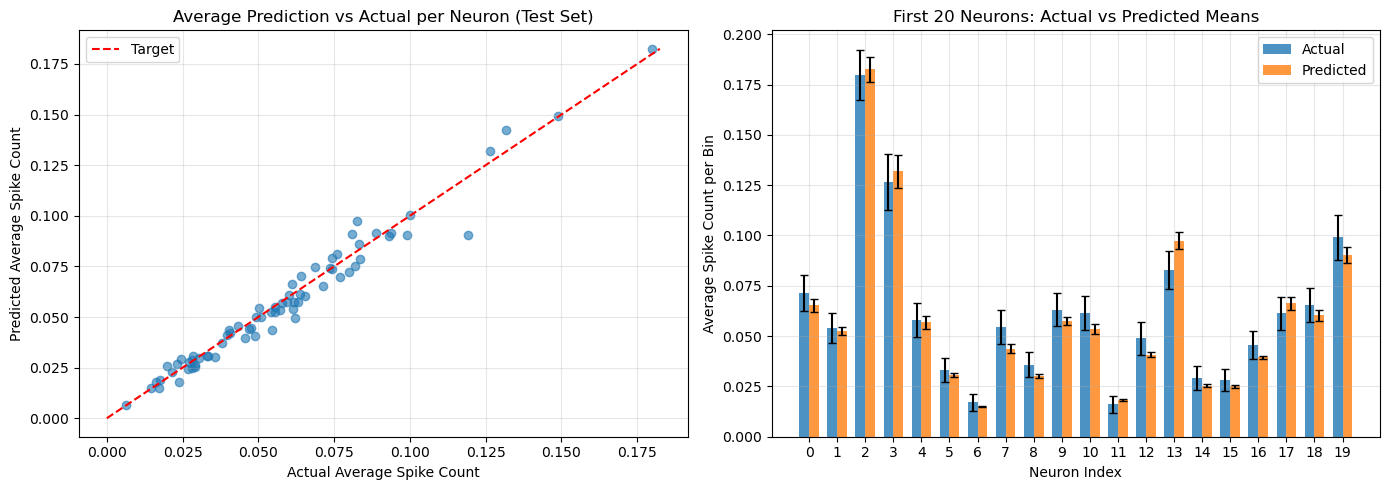

In [25]:
from viz import plot_test_prediction_comparison, analyze_pattern_responses_by_pattern_name, plot_pattern_selectivity

model.eval()
all_preds, all_targets = [], []
with torch.no_grad():
    for bx, by in test_loader:
        bx = bx.to(device)
        preds = torch.exp(model(bx)).cpu().numpy()   # exp → rates
        all_preds.append(preds)
        all_targets.append(by.numpy())
all_preds   = np.concatenate(all_preds,   axis=0)   # (N, n_neurons, n_output_bins)
all_targets = np.concatenate(all_targets, axis=0)
os.makedirs('results/viz', exist_ok=True)
fig = plot_test_prediction_comparison(np.log(all_preds) + 1e-8, all_targets, savepath='results/viz/test_prediction_comparison.png')
plt.show()


Found 100 unique oracle patterns in test set


/Users/shubhom/anaconda3/envs/3_11/lib/python3.11/site-packages/torch/utils/data/dataloader.py:1117: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Samples per pattern: min=10, max=10, mean=10.0


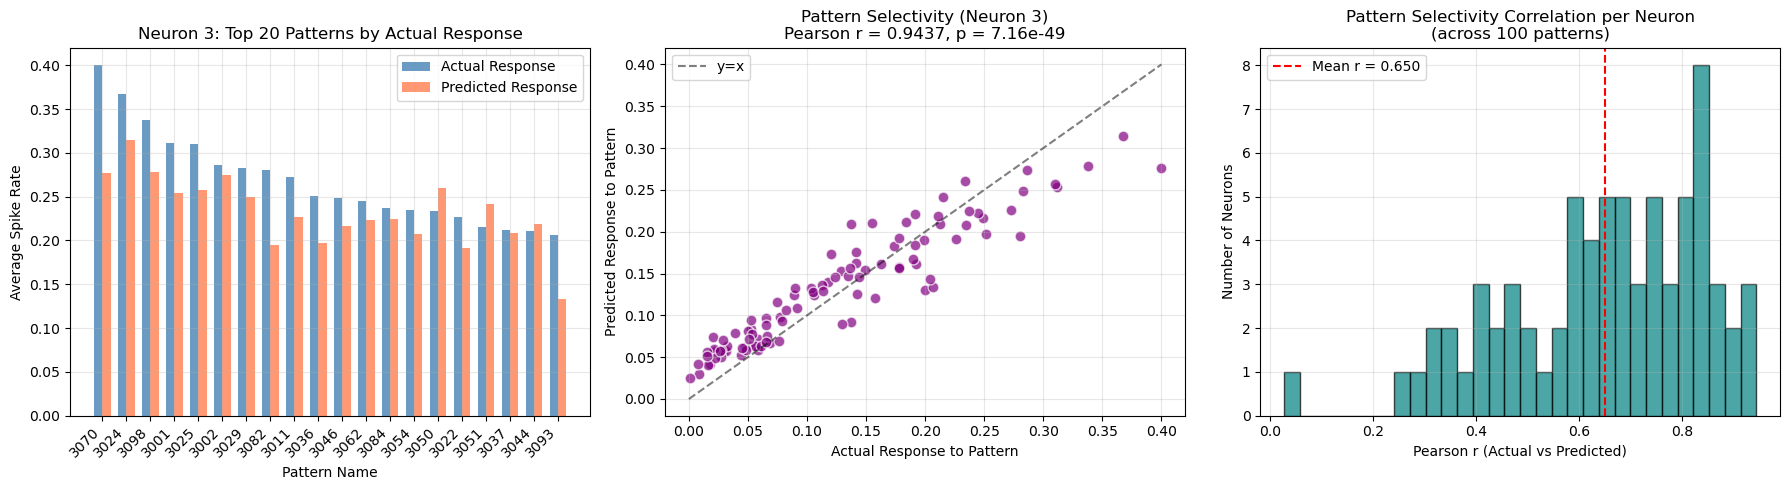

Mean r across neurons: 0.650
Neurons with r > 0.3:  69 / 72


In [26]:
pattern_names, pat_true, pat_pred, pat_counts = analyze_pattern_responses_by_pattern_name(
    model, test_ds, device, use_init_state=False
)
fig, axes, neuron_correlations = plot_pattern_selectivity(
    pattern_names, pat_true, pat_pred,
    savepath='results/viz/pattern_selectivity_analysis.png'
)
plt.show()
print(f"Mean r across neurons: {np.mean(neuron_correlations):.3f}")
print(f"Neurons with r > 0.3:  {(neuron_correlations > 0.3).sum()} / {len(neuron_correlations)}")


Sliding window: 10 ms = 1 fine bins (fine bin = 10 ms)


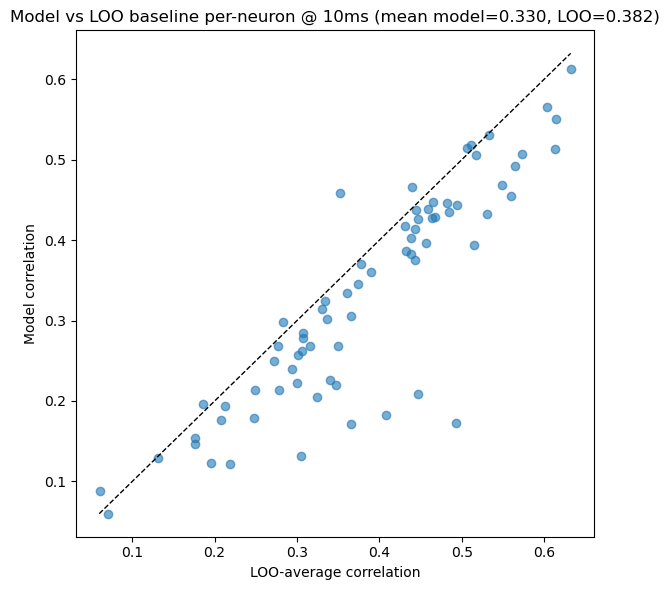

In [98]:
from collections import defaultdict
from scipy.stats import pearsonr

# --- Sliding window for coarse-grained comparison ------------------------
# COARSE_BIN_MS must be a multiple of the model's output_bin_size_ms.
# Set to test_ds.output_bin_size to disable windowing.
COARSE_BIN_MS = 10

def _sliding_sum_time(arr, win_bins):
    """Sliding window sum along the last (time) axis. Output shape:
    (..., T - win_bins + 1)."""
    if win_bins <= 1:
        return arr
    c = np.cumsum(arr, axis=-1)
    # prepend zero along time axis
    pad_shape = list(arr.shape); pad_shape[-1] = 1
    c = np.concatenate([np.zeros(pad_shape, dtype=c.dtype), c], axis=-1)
    return c[..., win_bins:] - c[..., :-win_bins]

fine_bin_ms = test_ds.output_bin_size
assert COARSE_BIN_MS % fine_bin_ms == 0, "COARSE_BIN_MS must be a multiple of output_bin_size_ms"
win_bins = COARSE_BIN_MS // fine_bin_ms
print(f"Sliding window: {COARSE_BIN_MS} ms = {win_bins} fine bins (fine bin = {fine_bin_ms} ms)")

pattern_to_timing = defaultdict(list)
for timing_idx in test_ds.trial_indices:
    pattern_to_timing[test_ds.timing_to_pattern[timing_idx]].append(timing_idx)

loo_preds, loo_targets = [], []
for i in range(len(test_ds)):
    timing_idx, t = test_ds.samples[i]
    pname  = test_ds.timing_to_pattern[timing_idx]
    others = [ti for ti in pattern_to_timing[pname] if ti != timing_idx]
    if not others:
        continue
    true_win  = test_ds.spike_responses_binned[timing_idx][:, t + test_ds.output_offset : t + test_ds.output_offset + test_ds.n_output_bins]
    loo_win   = np.mean([test_ds.spike_responses_binned[ti][:, t + test_ds.output_offset : t + test_ds.output_offset + test_ds.n_output_bins] for ti in others], axis=0)
    loo_targets.append(true_win)
    loo_preds.append(loo_win)
loo_preds   = np.stack(loo_preds)
loo_targets = np.stack(loo_targets)

# Apply sliding window. all_preds are predicted spike counts per fine bin;
# summing over win_bins gives expected count in the window, matching summed GT.
loo_preds_w     = _sliding_sum_time(loo_preds,                       win_bins)
loo_targets_w   = _sliding_sum_time(loo_targets,                     win_bins)
model_preds_w   = _sliding_sum_time(all_preds[:len(loo_preds)],      win_bins)
model_targets_w = _sliding_sum_time(all_targets[:len(loo_preds)],    win_bins)

# per-neuron correlation
def per_neuron_corr(pred, true):
    corrs = []
    for n in range(pred.shape[1]):
        p = pred[:, n, :].ravel()
        t = true[:, n, :].ravel()
        if p.std() > 0 and t.std() > 0:
            corrs.append(pearsonr(p, t)[0])
        else:
            corrs.append(0)
    return np.array(corrs)

model_corr = per_neuron_corr(model_preds_w, model_targets_w)
loo_corr   = per_neuron_corr(loo_preds_w,   loo_targets_w)

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(loo_corr, model_corr, alpha=0.6)
lo, hi = min(loo_corr.min(), model_corr.min()), max(loo_corr.max(), model_corr.max())
ax.plot([lo, hi], [lo, hi], 'k--', lw=1)
ax.set_xlabel('LOO-average correlation'); ax.set_ylabel('Model correlation')
ax.set_title(f'Model vs LOO baseline per-neuron @ {COARSE_BIN_MS}ms '
             f'(mean model={model_corr.mean():.3f}, LOO={loo_corr.mean():.3f})')
plt.tight_layout(); plt.savefig(f'results/viz/model_vs_LOO_{COARSE_BIN_MS}ms.png', dpi=100); plt.show()


In [27]:
def plot_trial_comparison(timing_idx, test_ds, model, device, savepath=None,
                          coarse_bin_ms=None):
    """Compare model prediction vs LOO average vs actual spikes for one trial.

    If ``coarse_bin_ms`` is provided (and > output_bin_size), all three traces
    are re-binned with a sliding window of that width (overlapping, stride = 1
    fine bin). This makes slow features easier to see without changing the
    model\'s output resolution.
    """
    pname = test_ds.timing_to_pattern[timing_idx]
    stim = pattern_stims[pname]                          # (n_ch, stim_ms) 1ms resolution
    pol  = pattern_polarities[pname]
    signed_stim = stim * pol

    # --- Ground truth (binned) ---
    gt = test_ds.spike_responses_binned[timing_idx]      # (n_neurons, n_output_bins_total)

    # --- Model prediction: sliding-window, teacher-forced ---
    from models import sliding_window_predict_trial
    cfg = dict(
        n_input_bins=test_ds.n_input_bins,
        n_output_bins=test_ds.n_output_bins,
        output_bin_size_ms=test_ds.output_bin_size,
        input_bin_size_ms=test_ds.input_bin_size,
        max_time_ms=test_ds.max_time_ms,
        output_offset=test_ds.output_offset,
        history=test_ds.history or 0,
        init_state=test_ds.init_state,
    )
    pred = sliding_window_predict_trial((model, None, device), cfg, test_loader, timing_idx)
    # --- LOO average: mean of ground truth from other trials of the same pattern ---
    others = [ti for ti in test_ds.trial_indices
              if test_ds.timing_to_pattern[ti] == pname and ti != timing_idx]
    loo = np.mean([test_ds.spike_responses_binned[ti] for ti in others], axis=0) if others else np.zeros_like(gt)

    fine_bin_ms = test_ds.output_bin_size
    if coarse_bin_ms is None or coarse_bin_ms <= fine_bin_ms:
        win_bins = 1
        coarse_bin_ms = fine_bin_ms
    else:
        assert coarse_bin_ms % fine_bin_ms == 0, "coarse_bin_ms must be a multiple of output_bin_size_ms"
        win_bins = coarse_bin_ms // fine_bin_ms

        def _sw(arr):
            c = np.cumsum(arr, axis=-1)
            pad_shape = list(arr.shape); pad_shape[-1] = 1
            c = np.concatenate([np.zeros(pad_shape, dtype=c.dtype), c], axis=-1)
            return c[..., win_bins:] - c[..., :-win_bins]
        pred = _sw(pred)
        gt   = _sw(gt)
        loo  = _sw(loo)

    print ("Pred shape", pred.shape, "GT shape", gt.shape, f"(win={win_bins} x {fine_bin_ms}ms = {coarse_bin_ms}ms)")

    # Time axis in ms. Sliding window centres each bin at (k + win_bins/2) * fine_bin_ms
    # Use window centre for plotting so stim/response align visually.
    t_out_centres = (np.arange(pred.shape[1]) + win_bins / 2.0) * fine_bin_ms
    x_lo, x_hi = t_out_centres[0] - fine_bin_ms/2, t_out_centres[-1] + fine_bin_ms/2

    vmax = max(pred.max(), gt.max(), loo.max())

    fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True,
                             gridspec_kw={'height_ratios': [1, 2, 2, 2]})

    # 1. Stim pattern (1 ms resolution)
    axes[0].imshow(signed_stim, aspect='auto', cmap='RdBu_r', vmin=-3, vmax=3,
                   interpolation='nearest',
                   extent=[0, stim.shape[1], signed_stim.shape[0], 0])
    axes[0].set_ylabel('Stim ch'); axes[0].set_title(f'Pattern {pname}  (timing_idx={timing_idx})')

    # 2. Model prediction
    im1 = axes[1].imshow(pred, aspect='auto', cmap='viridis', vmin=0, vmax=vmax,
                         interpolation='nearest',
                         extent=[x_lo, x_hi, pred.shape[0], 0])
    axes[1].set_ylabel('Neuron'); axes[1].set_title(f'Model prediction ({coarse_bin_ms}ms sliding sum)')
    plt.colorbar(im1, ax=axes[1], fraction=0.02)

    # 3. LOO average
    im2 = axes[2].imshow(loo, aspect='auto', cmap='viridis', vmin=0, vmax=vmax,
                         interpolation='nearest',
                         extent=[x_lo, x_hi, loo.shape[0], 0])
    axes[2].set_ylabel('Neuron'); axes[2].set_title(f'LOO average (n={len(others)} trials, {coarse_bin_ms}ms sum)')
    plt.colorbar(im2, ax=axes[2], fraction=0.02)

    # 4. Actual
    im3 = axes[3].imshow(gt, aspect='auto', cmap='viridis', vmin=0, vmax=vmax,
                         interpolation='nearest',
                         extent=[x_lo, x_hi, gt.shape[0], 0])
    axes[3].set_ylabel('Neuron'); axes[3].set_xlabel('Time (ms)')
    axes[3].set_title(f'Actual spikes ({coarse_bin_ms}ms sum)')
    plt.colorbar(im3, ax=axes[3], fraction=0.02)

    plt.tight_layout()
    if savepath: fig.savefig(savepath, dpi=100)
    return fig

# Pick a test trial and plot

Pred shape (72, 80) GT shape (72, 80) (win=1 x 10ms = 10ms)


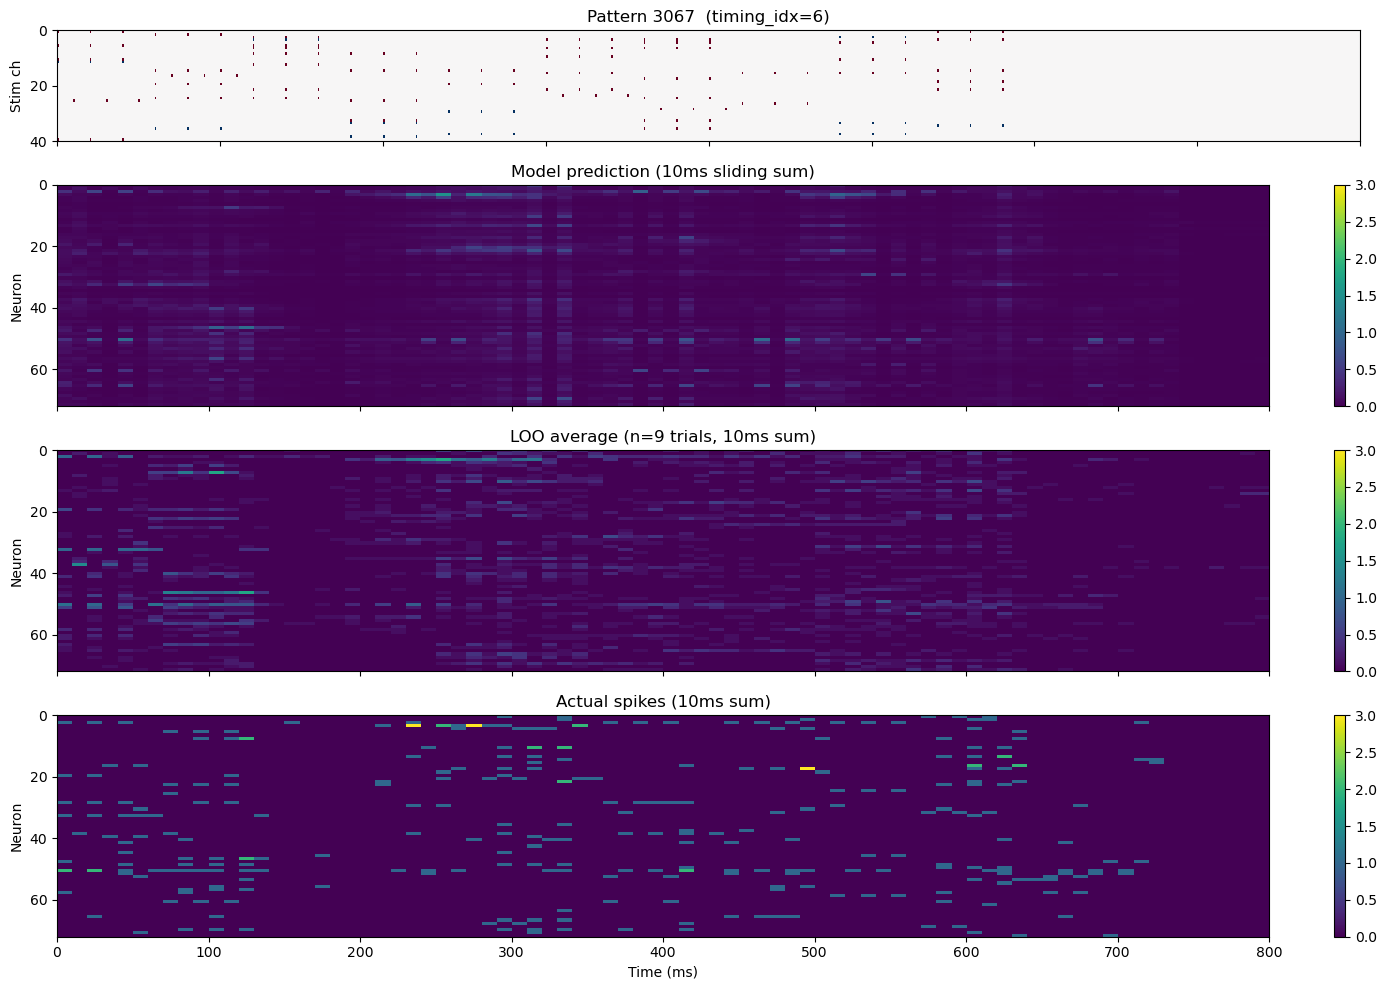

In [28]:

sample_timing = test_ds.trial_indices[3]
plot_trial_comparison(sample_timing, test_ds, model, device,
                      coarse_bin_ms=10,
                      savepath=f'results/viz/trial_comparison_{sample_timing}.png')
plt.show()


Sample idx=80  timing_idx=2457  pattern=1807  t=0
  in_bin=10ms, out_bin=10ms, n_init=6, history=1
  stim input window ms : [-60, 800)  (first 60 ms is zero-pad context)
  target  window ms    : [0, 800)
  stim input cols: first 6 are zero-pad, col 6 = ms 0 of current trial
  raw stim 1ms values at ms [-10, 0, 10, 20, 30]: [0.0, 3.0, 3.0, 3.0, 3.0]


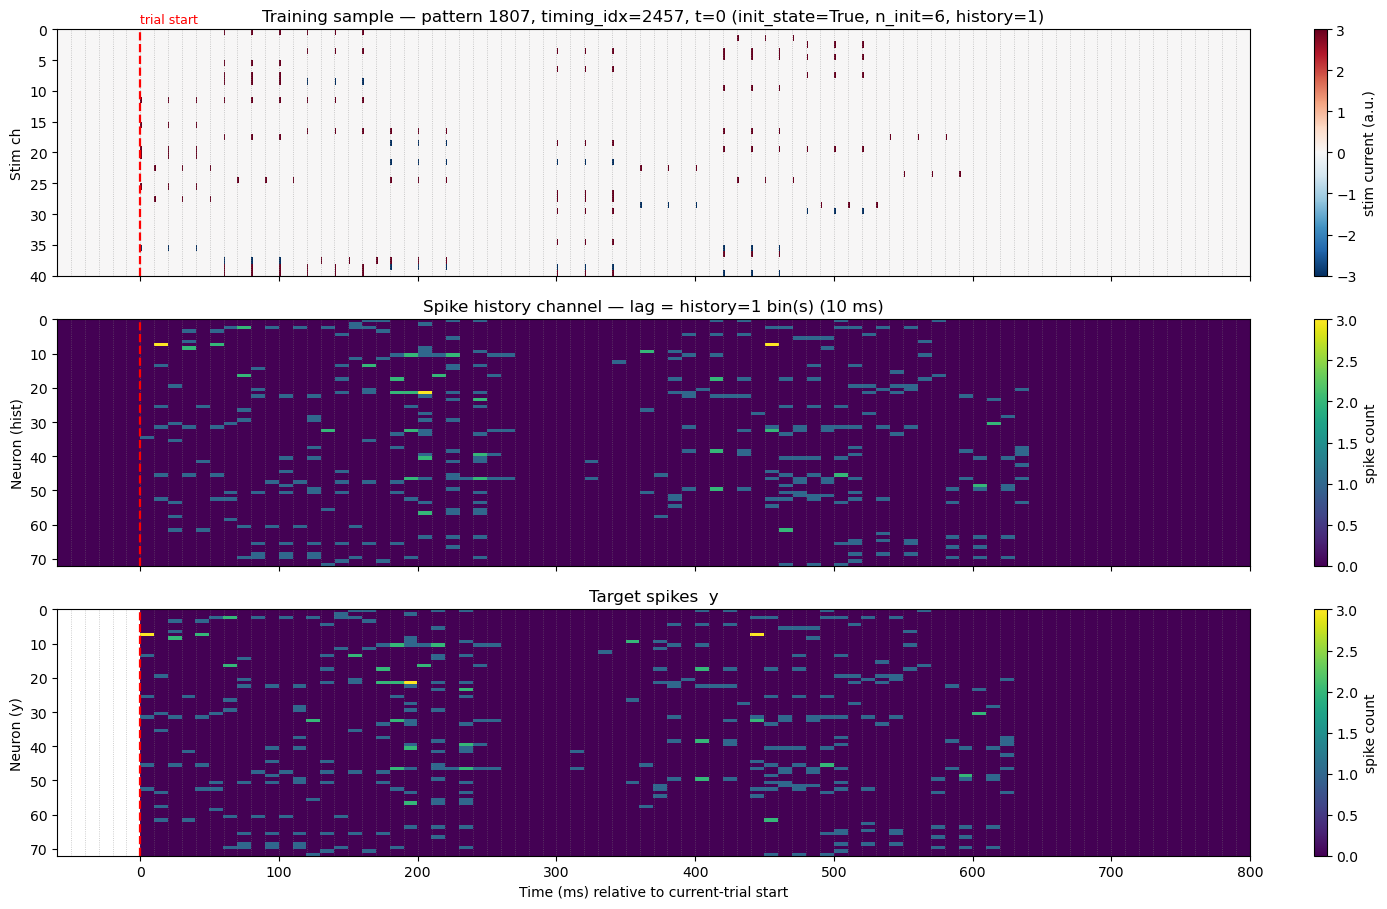

In [75]:
# Visualize a single training sample exactly as __getitem__ returns it.
# Top    : stim channels at 1 ms resolution (the raw pattern), with vertical
#          dashed lines at every input-bin boundary. The first n_init bins
#          before the red line are the zero-padded "previous-trial" context
#          that the valid conv consumes.
# Middle : spike history channel (from __getitem__, output-bin resolution).
# Bottom : target spikes y (output-bin resolution).
# Red dashed vertical line marks current-trial start (t = 0 ms).

SAMPLE_IDX = 80
ds = train_ds

x, y = ds[SAMPLE_IDX]
x = x.numpy()
y = y.numpy()

timing_idx, t = ds.samples[SAMPLE_IDX]
pname   = ds.timing_to_pattern[timing_idx]
n_stim  = ds.n_channels
history_val = ds.history if (ds.history is not None and ds.history > 0) else 0
n_init  = ds.n_initial_state_bins if ds.init_state else 0
in_bin  = ds.input_bin_size
out_bin = ds.output_bin_size

stim_block_binned = x[:n_stim]                             # (n_stim, x_width) at in_bin ms
hist_block        = x[n_stim:] if history_val > 0 else None

x_width = stim_block_binned.shape[1]

# Current-trial time of column k in the binned stim (stim_full[:, t:t+x_width]
# where stim_full has n_init zeros prepended): trial_ms = (t + k - n_init) * in_bin
x_left_ms  = (t - n_init) * in_bin
x_right_ms = x_left_ms + x_width * in_bin

# --- 1 ms raw stim for the stim panel --------------------------------------
# pattern_stims[pname] is at 1 ms resolution (shape: n_stim_ch, max_time_ms).
raw_stim_1ms = pattern_stims[pname].astype(np.float32) * pattern_polarities[pname].astype(np.float32)

# Slice the same current-trial ms range, padding with zeros where negative / out of range.
win_ms = np.arange(int(x_left_ms), int(x_right_ms))         # shape (x_width * in_bin,)
stim_1ms_slice = np.zeros((n_stim, win_ms.size), dtype=np.float32)
valid = (win_ms >= 0) & (win_ms < raw_stim_1ms.shape[1])
stim_1ms_slice[:, valid] = raw_stim_1ms[:, win_ms[valid]]

# --- target y axis in ms ---------------------------------------------------
y_left_ms  = (t + ds.output_offset) * out_bin
y_right_ms = y_left_ms + y.shape[1] * out_bin

# --- hist block axis in ms (same grid as stim input) -----------------------
# hist_block aligns with the binned stim window.
h_left_ms  = x_left_ms
h_right_ms = x_right_ms

print(f"Sample idx={SAMPLE_IDX}  timing_idx={timing_idx}  pattern={pname}  t={t}")
print(f"  in_bin={in_bin}ms, out_bin={out_bin}ms, n_init={n_init}, history={history_val}")
print(f"  stim input window ms : [{x_left_ms}, {x_right_ms})  (first {n_init*in_bin} ms is zero-pad context)")
print(f"  target  window ms    : [{y_left_ms}, {y_right_ms})")

# Diagnostic: show which stim input column is the first "real" (post-pad) one,
# and which 1 ms samples fall at / just after trial start.
print(f"  stim input cols: first {n_init} are zero-pad, col {n_init} = ms 0 of current trial")
if stim_1ms_slice.shape[1] >= abs(int(x_left_ms)) + 30:
    first_real_ms = -int(x_left_ms)  # index into stim_1ms_slice where ms=0 sits
    print(f"  raw stim 1ms values at ms [-10, 0, 10, 20, 30]: "
          f"{[float(stim_1ms_slice[:, first_real_ms + k].max()) if 0 <= first_real_ms+k < stim_1ms_slice.shape[1] else float('nan') for k in (-10, 0, 10, 20, 30)]}")

n_rows = 3 if hist_block is not None else 2
fig, axes = plt.subplots(n_rows, 1, figsize=(14, 2.4 * n_rows + 2), sharex=True,
                         gridspec_kw={'height_ratios': [2] * n_rows})

vabs = max(1.0, float(np.abs(stim_1ms_slice).max()))

# --- 1. stim channels at 1 ms ---
ax = axes[0]
im = ax.imshow(stim_1ms_slice, aspect='auto', cmap='RdBu_r',
               vmin=-vabs, vmax=vabs, interpolation='nearest',
               extent=[x_left_ms, x_right_ms, stim_1ms_slice.shape[0], 0])
ax.set_ylabel('Stim ch')
ax.set_title(f'Training sample — pattern {pname}, timing_idx={timing_idx}, t={t} '
             f'(init_state={ds.init_state}, n_init={n_init}, history={history_val})')
plt.colorbar(im, ax=ax, fraction=0.02, label='stim current (a.u.)')

# --- 2. spike history ---
row = 1
if hist_block is not None:
    ax = axes[row]; row += 1
    im = ax.imshow(hist_block, aspect='auto', cmap='viridis', interpolation='nearest',
                   extent=[h_left_ms, h_right_ms, hist_block.shape[0], 0])
    ax.set_ylabel('Neuron (hist)')
    ax.set_title(f'Spike history channel — lag = history={history_val} bin(s) ({history_val*in_bin} ms)')
    plt.colorbar(im, ax=ax, fraction=0.02, label='spike count')

# --- 3. target y ---
ax = axes[row]
im = ax.imshow(y, aspect='auto', cmap='viridis', interpolation='nearest',
               extent=[y_left_ms, y_right_ms, y.shape[0], 0])
ax.set_ylabel('Neuron (y)')
ax.set_xlabel('Time (ms) relative to current-trial start')
ax.set_title('Target spikes  y')
plt.colorbar(im, ax=ax, fraction=0.02, label='spike count')

# --- Shared: red line at current-trial start, dashed grey lines at every input-bin boundary ---
bin_edges = np.arange(x_left_ms, x_right_ms + 1, in_bin)
for a in axes:
    for edge in bin_edges:
        a.axvline(edge, color='grey', ls=':', lw=0.6, alpha=0.5)
    a.axvline(0, color='red', ls='--', lw=1.6)
    a.set_xlim(x_left_ms, x_right_ms)

# Annotate start line on top panel
axes[0].text(0, -0.6, 'trial start', color='red', va='bottom', ha='left', fontsize=9)

plt.tight_layout()
os.makedirs('results/viz', exist_ok=True)
fig.savefig(f'results/viz/training_sample_{SAMPLE_IDX}.png', dpi=100)
plt.show()


In [73]:
x, y = train_ds[0]
y_hist = x[-n_neurons:]          # last n_neurons channels are history
print("y nonzero frac:", (y > 0).float().mean().item())
print("y_hist nonzero frac:", (y_hist > 0).float().mean().item())
# y_hist at col c should equal y at col c-1 (roughly)
print("match:", torch.allclose(y_hist[:, 1:y.shape[1]], y[:, :-1]))


y nonzero frac: 0.05017361044883728
y_hist nonzero frac: 0.04683462530374527
match: False


Total step occurrences: 36697
  across 4000 trials, 3100 patterns
Deviation  mean=35.483 ms, std=46.956 ms, median=20.700 ms, min=0.000, max=330.133

Oracle patterns: 100, (pattern, step) cells with >=2 repeats: 922
 step_index  mean_dev  sd_across_patterns  mean_within_pattern_sd  n_patterns
          0  0.000000            0.000000                0.000000          94
          1 17.431773           37.938338                8.292671          94
          2 22.193404           38.154490               10.062676          94
          3 27.413480           38.792403               11.987072          91
          4 31.978370           38.517612               13.466015          92
          5 37.668333           38.739383               15.913092          90
          6 40.058951           35.591583               16.497813          89
          7 46.124946           38.343254               18.646441          93
          8 50.609203           39.018015               19.825304          92
    

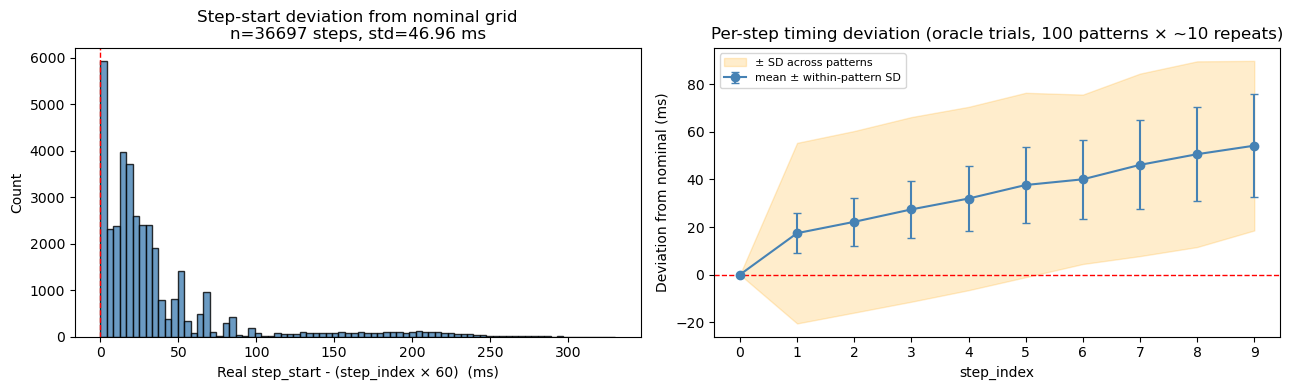

In [70]:
# Diagnostic: how much does the real step_start_timestamp deviate from the
# nominal step_index * 60 ms?  Two plots:
#   1. Histogram of deviation (ms) pooled over ALL pattern/step occurrences.
#   2. Per-step mean deviation with SD error bars, computed over oracle trials
#      (10 repeats per pattern) — shows within-pattern timing reproducibility.

# Real step start in ms, relative to pattern start.
step_df = pattern_df[['pattern_name', 'pattern_timing_index', 'step_index',
                      'pattern_flag_start_timestamp', 'step_start_timestamp',
                      'is_oracle']].drop_duplicates(
    subset=['pattern_timing_index', 'step_index']
).copy()
step_df['step_real_ms']    = (step_df['step_start_timestamp'] - step_df['pattern_flag_start_timestamp']) / 30.0
step_df['step_nominal_ms'] = step_df['step_index'].astype(int) * 60
step_df['deviation_ms']    = step_df['step_real_ms'] - step_df['step_nominal_ms']

# Restrict to valid steps (first 10).
step_df = step_df[(step_df['step_index'].astype(int) >= 0) &
                  (step_df['step_index'].astype(int) < 10)].copy()

print(f"Total step occurrences: {len(step_df)}")
print(f"  across {step_df['pattern_timing_index'].nunique()} trials, "
      f"{step_df['pattern_name'].nunique()} patterns")
print(f"Deviation  mean={step_df['deviation_ms'].mean():.3f} ms, "
      f"std={step_df['deviation_ms'].std():.3f} ms, "
      f"median={step_df['deviation_ms'].median():.3f} ms, "
      f"min={step_df['deviation_ms'].min():.3f}, max={step_df['deviation_ms'].max():.3f}")

# ---- 1. Pooled histogram ----
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
ax = axes[0]
ax.hist(step_df['deviation_ms'], bins=80, color='steelblue', edgecolor='black', alpha=0.8)
ax.axvline(0, color='red', ls='--', lw=1)
ax.set_xlabel('Real step_start - (step_index × 60)  (ms)')
ax.set_ylabel('Count')
ax.set_title(f'Step-start deviation from nominal grid\n'
             f'n={len(step_df)} steps, std={step_df["deviation_ms"].std():.2f} ms')

# ---- 2. Per-step, per-pattern mean ± SD across oracle repeats ----
oracle_df = step_df[step_df['is_oracle'] == True].copy()
# For each (pattern, step_index) pair, compute mean & SD across trials.
per_pat_step = (oracle_df.groupby(['pattern_name', 'step_index'])['deviation_ms']
                .agg(['mean', 'std', 'count']).reset_index())
per_pat_step = per_pat_step[per_pat_step['count'] >= 2]  # need >=2 repeats for SD
print(f"\nOracle patterns: {oracle_df['pattern_name'].nunique()}, "
      f"(pattern, step) cells with >=2 repeats: {len(per_pat_step)}")

# Then aggregate across patterns to get per-step summary.
per_step = (per_pat_step.groupby('step_index')
            .agg(mean_dev=('mean', 'mean'),
                 sd_across_patterns=('mean', 'std'),
                 mean_within_pattern_sd=('std', 'mean'),
                 n_patterns=('mean', 'count')).reset_index())
print(per_step.to_string(index=False))

ax = axes[1]
x = per_step['step_index'].astype(int).values
ax.errorbar(x, per_step['mean_dev'], yerr=per_step['mean_within_pattern_sd'],
            fmt='o-', color='steelblue', capsize=3, label='mean ± within-pattern SD')
ax.fill_between(x,
                per_step['mean_dev'] - per_step['sd_across_patterns'],
                per_step['mean_dev'] + per_step['sd_across_patterns'],
                alpha=0.2, color='orange', label='± SD across patterns')
ax.axhline(0, color='red', ls='--', lw=1)
ax.set_xlabel('step_index')
ax.set_ylabel('Deviation from nominal (ms)')
ax.set_title(f'Per-step timing deviation (oracle trials, '
             f'{oracle_df["pattern_name"].nunique()} patterns × ~10 repeats)')
ax.set_xticks(x)
ax.legend(loc='best', fontsize=8)

plt.tight_layout()
os.makedirs('results/viz', exist_ok=True)
fig.savefig('results/viz/step_timing_deviation.png', dpi=100)
plt.show()


Using 4000  trials


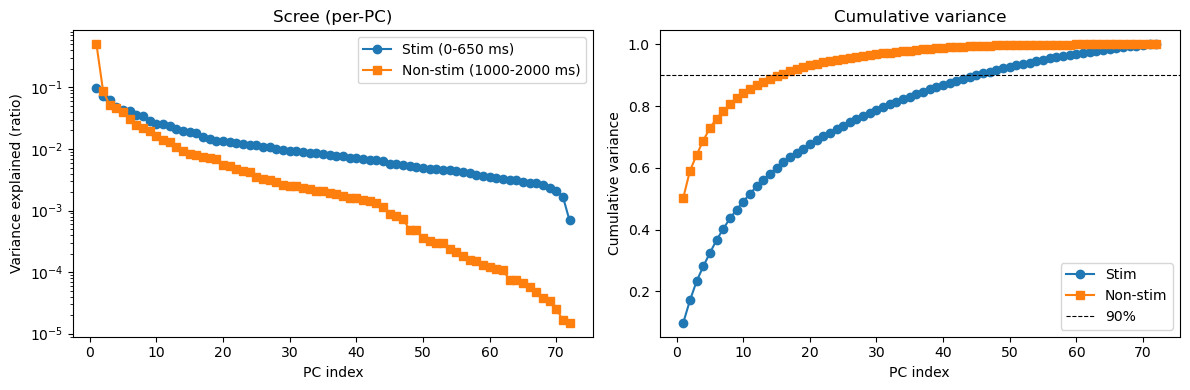

Dim@90% — stim: 45, non-stim: 16


In [16]:
# PCA on stim and non-stim periods
from sklearn.decomposition import PCA

STIM_WIN   = (0, 650)        # ms — during stimulation
NONSTIM_WIN = (2000-1000-10, 2000-10)   # ms — spontaneous/post-stim
ORACLE_ONLY = False          # whether to restrict to oracle trials (>=2 repeats per pattern)

# Use oracle trials (patterns with >1 repeat)
if ORACLE_ONLY:
    timings = [ti for ti in spike_responses.keys()
                    if unique_trials[unique_trials['pattern_timing_index']==ti]['is_oracle'].any()]
else:
    timings = list(spike_responses.keys())
print(f"Using {len(timings)}  trials")

# Build response vectors: one per trial per pattern, n_neurons long
stim_vecs, nonstim_vecs = [], []
for ti in timings:
    spk = spike_responses[ti]    # (n_neurons, 2000) at 1ms
    stim_vecs.append(spk[:, STIM_WIN[0]:STIM_WIN[1]].sum(axis=1))
    nonstim_vecs.append(spk[:, NONSTIM_WIN[0]:NONSTIM_WIN[1]].sum(axis=1))

stim_mat    = np.stack(stim_vecs)     # (n_trials, n_neurons)
nonstim_mat = np.stack(nonstim_vecs)

# Fit PCA on each
pca_stim    = PCA().fit(stim_mat)
pca_nonstim = PCA().fit(nonstim_mat)

# Scree plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(np.arange(1, len(pca_stim.explained_variance_ratio_)+1),
             pca_stim.explained_variance_ratio_, 'o-', label='Stim (0-650 ms)')
axes[0].plot(np.arange(1, len(pca_nonstim.explained_variance_ratio_)+1),
             pca_nonstim.explained_variance_ratio_, 's-', label='Non-stim (1000-2000 ms)')
axes[0].set_xlabel('PC index'); axes[0].set_ylabel('Variance explained (ratio)')
axes[0].set_yscale('log'); axes[0].legend(); axes[0].set_title('Scree (per-PC)')

axes[1].plot(np.arange(1, len(pca_stim.explained_variance_ratio_)+1),
             np.cumsum(pca_stim.explained_variance_ratio_), 'o-', label='Stim')
axes[1].plot(np.arange(1, len(pca_nonstim.explained_variance_ratio_)+1),
             np.cumsum(pca_nonstim.explained_variance_ratio_), 's-', label='Non-stim')
axes[1].axhline(0.9, color='k', ls='--', lw=0.8, label='90%')
axes[1].set_xlabel('PC index'); axes[1].set_ylabel('Cumulative variance')
axes[1].legend(); axes[1].set_title('Cumulative variance')

plt.tight_layout(); plt.savefig('results/viz/pca_dimensionality.png', dpi=100); plt.show()

# Print effective dim (PCs to reach 90% var)
def dim_90(pca): return np.searchsorted(np.cumsum(pca.explained_variance_ratio_), 0.9) + 1
print(f"Dim@90% — stim: {dim_90(pca_stim)}, non-stim: {dim_90(pca_nonstim)}")



In [43]:
VIS_WIN = (0, 500)   # ms post visual onset
SAMPLES_30KHZ = 30 # 15000 frames = 0.5 s

vstim_onsets = np.load('data/VStim_Onset_TS.npy')
vstim_labels = np.load('data/VStim_Labels.npy')

vis_vecs = []
for onset in vstim_onsets:
    start = onset + VIS_WIN[0] * SAMPLES_30KHZ
    end   = onset + VIS_WIN[1] * SAMPLES_30KHZ
    trial_spk = spikes_df[(spikes_df['timestamp'] >= start) & (spikes_df['timestamp'] < end)]
    counts = np.zeros(n_neurons)
    for _, row in trial_spk.iterrows():
        counts[neuron_to_idx[row['neuron_id']]] += 1
    vis_vecs.append(counts / N_VIS_TRIALS)  # average spike count per neuron per trial
vis_spike_rate_per_ms = np.stack(vis_vecs)    # (n_vis_trials, n_neurons)
print(f"Visual trials: {vis_spike_rate_per_ms.shape}, summed over {VIS_WIN[1] - VIS_WIN[0]} ms and averaged over trials")


Visual trials: (1600, 72), summed over 500 ms and averaged over trials


Visual trials: (1600, 72), summed over 500 ms and averaged over trials


NameError: name 'pca_stim' is not defined

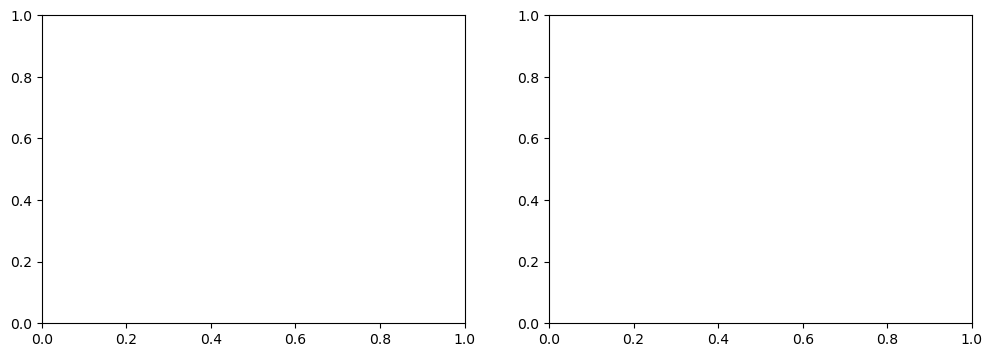

In [ ]:

pca_vis = PCA().fit(vis_spike_rate_per_ms)

# Scree with all 3
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for pca, label, marker in [(pca_stim, 'Stim (0-650 ms)', 'o'),
                            (pca_nonstim, 'Non-stim (1000-2000 ms)', 's'),
                            (pca_vis, 'Visual (0-500 ms)', '^')]:
    axes[0].plot(np.arange(1, len(pca.explained_variance_ratio_)+1),
                 pca.explained_variance_ratio_, marker=marker, label=label)
    axes[1].plot(np.arange(1, len(pca.explained_variance_ratio_)+1),
                 np.cumsum(pca.explained_variance_ratio_), marker=marker, label=label)

axes[0].set_xlabel('PC index'); axes[0].set_ylabel('Variance explained')
axes[0].set_yscale('log'); axes[0].legend(); axes[0].set_title('Scree')
axes[1].axhline(0.9, color='k', ls='--', lw=0.8)
axes[1].set_xlabel('PC index'); axes[1].set_ylabel('Cumulative variance')
axes[1].legend(); axes[1].set_title('Cumulative variance')
plt.tight_layout(); plt.savefig('results/viz/pca_dimensionality_all.png', dpi=100); plt.show()

print(f"Dim@90% — stim: {dim_90(pca_stim)}, non-stim: {dim_90(pca_nonstim)}, visual: {dim_90(pca_vis)}")


Principal angles (degrees, K=10 dims):
  Visual vs Stim    : [89.8 87.8 87.4 84.1 82.8 79.1 75.8 71.4 66.  55.5]
  Visual vs Non-stim: [89.6 80.5 58.7 44.4 37.6 26.2 23.8 18.9 14.9 12.7]
  Stim vs Non-stim  : [89.6 88.5 86.2 84.3 80.4 78.5 72.1 67.3 64.3 53.5]


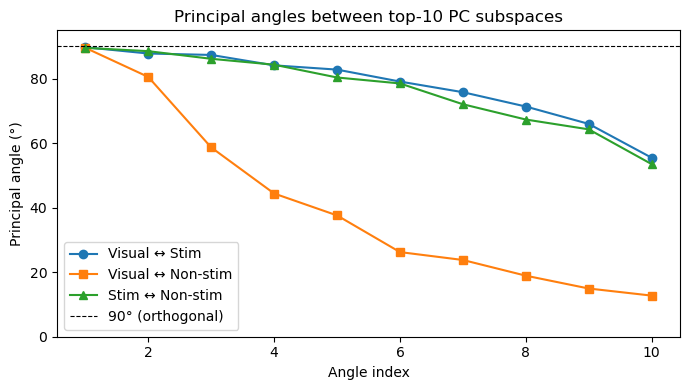

In [22]:
from scipy.linalg import subspace_angles

K = 10  # compare top-K PC subspaces
Q_vis  = pca_vis.components_[:K].T      # (n_neurons, K)
Q_stim = pca_stim.components_[:K].T     # (n_neurons, K)
Q_non  = pca_nonstim.components_[:K].T

angles_vs   = np.rad2deg(subspace_angles(Q_vis, Q_stim))
angles_vn   = np.rad2deg(subspace_angles(Q_vis, Q_non))
angles_sn   = np.rad2deg(subspace_angles(Q_stim, Q_non))

print(f"Principal angles (degrees, K={K} dims):")
print(f"  Visual vs Stim    : {angles_vs.round(1)}")
print(f"  Visual vs Non-stim: {angles_vn.round(1)}")
print(f"  Stim vs Non-stim  : {angles_sn.round(1)}")

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(np.arange(1, K+1), angles_vs, 'o-', label='Visual ↔ Stim')
ax.plot(np.arange(1, K+1), angles_vn, 's-', label='Visual ↔ Non-stim')
ax.plot(np.arange(1, K+1), angles_sn, '^-', label='Stim ↔ Non-stim')
ax.axhline(90, color='k', ls='--', lw=0.8, label='90° (orthogonal)')
ax.set_xlabel('Angle index'); ax.set_ylabel('Principal angle (°)')
ax.set_title(f'Principal angles between top-{K} PC subspaces')
ax.legend(); ax.set_ylim(0, 95)
plt.tight_layout(); plt.savefig('results/viz/principal_angles.png', dpi=100); plt.show()


In [23]:
# Check the actual overlap via full-rank projection, not just top-K
U_vis  = pca_vis.components_.T       # all PCs, full rank
U_stim = pca_stim.components_.T

# Cosine between top-1 PCs (±)
print("cos(PC1_vis, PC1_stim):", abs(U_vis[:,0] @ U_stim[:,0]))

# Check what fraction of variance in vis_mat lies in stim's top-K subspace
Q_stim_K = pca_stim.components_[:K].T
proj_var = ((vis_mat - vis_mat.mean(0)) @ Q_stim_K).var(axis=0).sum()
total_var = (vis_mat - vis_mat.mean(0)).var(axis=0).sum()
print(f"Fraction of vis variance in stim's top-{K} subspace: {proj_var/total_var:.3f}")


cos(PC1_vis, PC1_stim): 0.3150135082839709
Fraction of vis variance in stim's top-10 subspace: 0.095


In [ ]:
from torch.utils.data import DataLoader
from collections import defaultdict
import cvxpy as cp

# Use all trials (both oracle + non-oracle) for STA accumulation
all_ds = BinnedStimSpikeDataset(trial_indices=list(spike_responses.keys()), **dataset_kwargs)
all_loader = DataLoader(all_ds, batch_size=32, shuffle=False, num_workers=0)

model.eval()
sta_n_bins = 1
model_col_sum   = defaultdict(lambda: np.zeros((n_neurons, sta_n_bins), dtype=np.float64))
true_col_sum   = defaultdict(lambda: np.zeros((n_neurons, sta_n_bins), dtype=np.float64))

col_count = defaultdict(int)
@torch.no_grad()
def accumulate(loader, ds):
    sample_idx = 0
    for x, y_true in loader:
        x = x.to(device)
        y_hat = model(x).exp().cpu().numpy()    # (B, n_neurons, n_output_bins) # model predicts log-lambda at bin, so exp to get lambda=exp[spikes in bin]
        B = y_hat.shape[0]
        for b in range(B):
            timing_idx, t0 = ds.samples[sample_idx + b] # choose timing index and start time for this sample
            stim = ds.pattern_stims[ds.timing_to_pattern[timing_idx]]
            for t in range(N_OUTPUT_BINS):
                col_t = t + t0
                if col_t >= stim.shape[1]:
                    continue
                key = tuple(stim[:, col_t].tolist())
                if np.sum(np.abs(stim[:, col_t])) == 0:
                    continue  # skip zero-stim columns
                model_col_sum[key]   += y_hat[b, :, t:t+sta_n_bins] # add up model-predicted response for this stim col, in spikes/bin units
                true_col_sum[key]   += y_true.numpy()[b, :, t:t+sta_n_bins] # add up true response (spikes per bin)
                col_count[key] += 1
        sample_idx += B

accumulate(all_loader, all_ds)



# make sure that if you do single-electrode (exclude multi-electrode bins altgoether) there's enough samples

model_columns = np.array(list(model_col_sum.keys()), dtype=np.int64)
true_columns = np.array(list(true_col_sum.keys()), dtype=np.int64)

# compute STAs with electrode x amp columns
counts  = np.array([col_count[tuple(c)] for c in model_columns], dtype=np.int64)

# Contains unique stimulation pulses (of width 1 bin) and the average neural response to each pulse across all occurrences
gt_sta_matx_cols = np.stack(
    [true_col_sum[tuple(c)] / col_count[tuple(c)] for c in true_columns], axis=1
).astype(np.float32)

model_sta_matx_cols = np.stack(
    [model_col_sum[tuple(c)] / col_count[tuple(c)] for c in model_columns], axis=1
).astype(np.float32)

# apply single pulse mask
model_sta_matx_cols = model_sta_matx_cols[:, single_pulse_mask]
gt_sta_matx_cols = gt_sta_matx_cols[:, single_pulse_mask]

print(f'ground truth: unique stim columns: {len(true_columns)}, sta shape: {gt_sta_matx_cols.shape}')
print(f'model: unique stim columns: {len(model_columns)}, sta shape: {model_sta_matx_cols.shape}')


1 trials were added in spike responses for initial state that were not in the specified trial_indices
ground truth: unique stim columns: 24633, sta shape: (72, 79, 1)
model: unique stim columns: 24633, sta shape: (72, 79, 1)


In [39]:
model_columns.shape

(24633, 40)

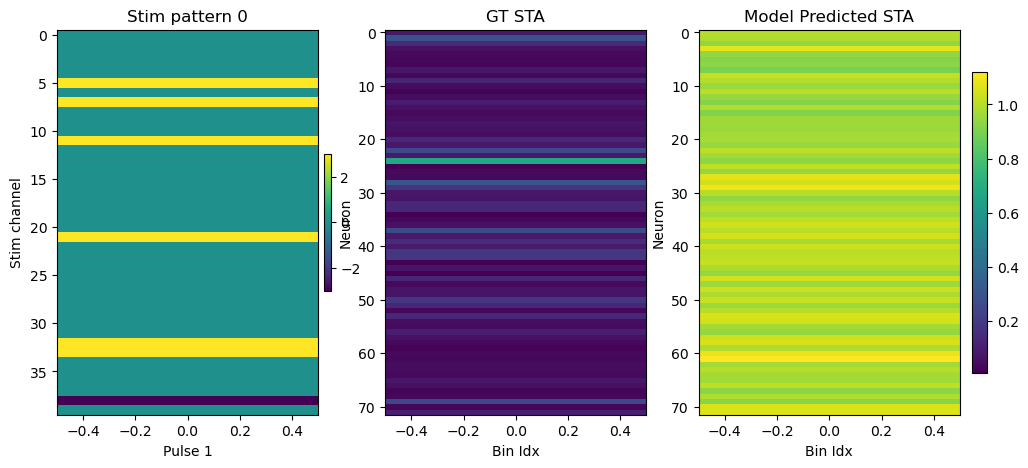

In [38]:
stim_idx = 0

stim_img = np.array(list(model_col_sum.keys())[stim_idx]).reshape(-1, 1)
gt_img    = gt_sta_matx_cols[:, stim_idx, :]
model_img = model_sta_matx_cols[:, stim_idx, :]

vmin = min(gt_img.min(), model_img.min())
vmax = max(gt_img.max(), model_img.max())

fig, axes = plt.subplots(1, 3, figsize=(12, 5), sharey=False)
im0 = axes[0].imshow(stim_img, aspect='auto')
axes[0].set_title(f'Stim pattern {stim_idx}')
axes[0].set_ylabel('Stim channel'); axes[0].set_xlabel('Pulse 1')

fig.colorbar(im0, ax=axes[0], fraction=0.025, pad=0.02)



im1 = axes[1].imshow(gt_img, aspect='auto', cmap='viridis', vmin=vmin, vmax=vmax)
axes[1].set_title(f'GT STA')
axes[1].set_ylabel('Neuron'); axes[1].set_xlabel('Bin Idx')
im2 = axes[2].imshow(model_img, aspect='auto', cmap='viridis', vmin=vmin, vmax=vmax)
axes[2].set_title(f'Model Predicted STA')
axes[2].set_ylabel('Neuron'); axes[2].set_xlabel('Bin Idx')


fig.colorbar(im2, ax=[axes[1], axes[2]], fraction=0.025, pad=0.02)
plt.show()

In [35]:
sta_single_pulse  = gt_sta_matx_cols[:, single_pulse_mask]
print(f'single-pulse columns: {single_pulse_mask.sum()} / {len(gt_sta_matx_cols)}')

BIN_TO_HZ = 1000.0 / OUTPUT_BIN_MS       # 10ms bin → 100 Hz multiplier
sta_matrix_hz = sta_single_pulse * BIN_TO_HZ


single-pulse columns: 79 / 72


In [40]:
class NNLS_Controller:
    def compute_stimulus(self, sta_matx, target_response, weight=None, l1=0.0):
        n_patterns = sta_matx.shape[1]
        x = cp.Variable(n_patterns, nonneg=True)
        A = (weight @ sta_matx) if weight is not None else sta_matx
        b = (weight @ target_response) if weight is not None else target_response
        objective = cp.Minimize(cp.sum_squares(A @ x - b) + l1 * cp.norm1(x))
        cp.Problem(objective).solve(solver=cp.OSQP, verbose=False)
        return x.value, np.linalg.norm(sta_matx @ x.value - target_response)
controller = NNLS_Controller()


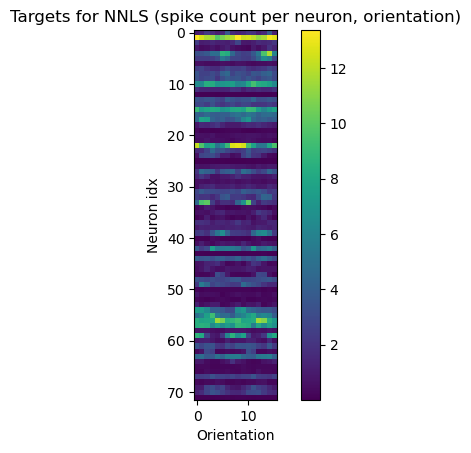

In [60]:
sum_responses.shape     # (n_orientations, n_neurons, N_BINS of 10 ms bins)

# Visual Int Time (how many bins to sum over)
VISUAL_INT_BINS = 50 # may reduce later
sum_responses_vis = sum_responses[:, :, :VISUAL_INT_BINS]

plt.title("Targets for NNLS (spike count per neuron, orientation)")
plt.imshow(sum_responses_vis.sum(axis=2).T)
plt.xlabel("Orientation")
plt.ylabel("Neuron idx")
plt.colorbar()

In [65]:
# vis_mat is (n_vis_trials, n_neurons) in spikes/ms from earlier PCA cell
sta_matx = gt_sta_matx_cols    # (n_neurons, n_single_pulse_columns)
# sta_matx = model_sta_matx_cols
# Group by orientation and average
orientations = np.unique(visual_stim_labels)
target_vectors = np.stack([
    sum_responses[idx].sum(axis=1) # spikes total
    for idx, ori  in enumerate(orientations)
])   # (n_orientations, n_neurons)
print(f'orientations: {orientations}, targets shape: {target_vectors.shape}')


orientations: [  0.   22.5  45.   67.5  90.  112.5 135.  157.5 180.  202.5 225.  247.5
 270.  292.5 315.  337.5], targets shape: (16, 72)


In [70]:
import plotly.graph_objects as go
# Build the 3D projection (CIS + PC1 + PC2) like SystemMouse does, but from real vis data
mean_vec = target_vectors.mean(axis=0)
pca_targets = PCA(n_components=2).fit(target_vectors)
proj, _ = np.linalg.qr(np.array([mean_vec, pca_targets.components_[0], pca_targets.components_[1]]).T)
# proj = np.array([pca_targets.components_[0], pca_targets.components_[1]]).T   
target_proj =  target_vectors @ proj       # (n_orientations, 3)
approx_proj = []
if sta_matx.ndim == 2:
    sta_matx = sta_matx[:, :, np.newaxis]  # add dummy bin axis for NNLS 
for i, ori in enumerate(orientations):
    target = target_vectors[i]
    weights, err = controller.compute_stimulus(sta_matx.sum(axis=2),target, weight=proj.T, l1=0.0)
    achieved = sta_matx.sum(axis=2) @ weights
    print(f'{ori:6.1f}°  |  active={( weights>1e-8).sum():3d}  residual={err:.2f}  '
          f'target_norm={np.linalg.norm(target)}')
    approx_proj.append(achieved @ proj)

approx_proj = np.array(approx_proj)
doubled = (orientations * 2) % 360    # cyclic colormap for 0-180°

fig = go.Figure()
if target_proj.ndim == 2:
    target_proj = np.hstack([target_proj, np.zeros((target_proj.shape[0], 1))])  # add dummy z=0 for 3D scatter
    approx_proj = np.hstack([approx_proj, np.zeros((approx_proj.shape[0], 1))])
fig.add_trace(go.Scatter3d(
    x=target_proj[:,0], y=target_proj[:,1], z=target_proj[:,2],
    mode='markers+text', name='Target (visual)',
    marker=dict(size=8, color=doubled, colorscale='HSV', cmin=0, cmax=360,
                colorbar=dict(title='Orientation (°)', tickvals=np.arange(0,361,72),
                              ticktext=[f'{int(v/2)}°' for v in np.arange(0,361,72)]),
                line=dict(color='black', width=1)),
    text=[f'{int(o)}°' for o in orientations], textposition='top center',
))
fig.add_trace(go.Scatter3d(
    x=approx_proj[:,0], y=approx_proj[:,1], z=approx_proj[:,2],
    mode='markers+text', name='NNLS achieved',
    marker=dict(size=6, color=doubled, colorscale='HSV', cmin=0, cmax=360, symbol='diamond',
                line=dict(color='black', width=1)),
    text=[f'~{int(o)}°' for o in orientations], textposition='bottom center',
))
fig.update_layout(
    title='STA-NNLS: reaching visual target responses via ICMS',
    scene=dict(xaxis_title='CIS', yaxis_title='PC1(Hz)', zaxis_title='PC2 (Hz)',
               aspectmode='data'),
    width=900, height=700,
)
fig.show()


   0.0°  |  active=24212  residual=37.37  target_norm=31.837166959388835
  22.5°  |  active=24212  residual=38.26  target_norm=32.274361341473515
  45.0°  |  active=24212  residual=37.77  target_norm=31.472113052669343
  67.5°  |  active=24212  residual=35.55  target_norm=29.94425487468339
  90.0°  |  active=24212  residual=33.73  target_norm=27.798240951542237
 112.5°  |  active=24212  residual=35.43  target_norm=29.1668476184863
 135.0°  |  active=24212  residual=36.15  target_norm=29.99607140943627
 157.5°  |  active=24212  residual=36.71  target_norm=30.589132056990433
 180.0°  |  active=24212  residual=36.80  target_norm=32.06841280762115
 202.5°  |  active=24212  residual=37.44  target_norm=32.02527127129449
 225.0°  |  active=24212  residual=39.09  target_norm=32.2511488167476
 247.5°  |  active=24212  residual=35.98  target_norm=29.965795500870655
 270.0°  |  active=24212  residual=35.53  target_norm=29.36971739734654
 292.5°  |  active=24212  residual=37.70  target_norm=30.675

/Users/shubhom/anaconda3/envs/3_11/lib/python3.11/site-packages/cvxpy/problems/problem.py:1539: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


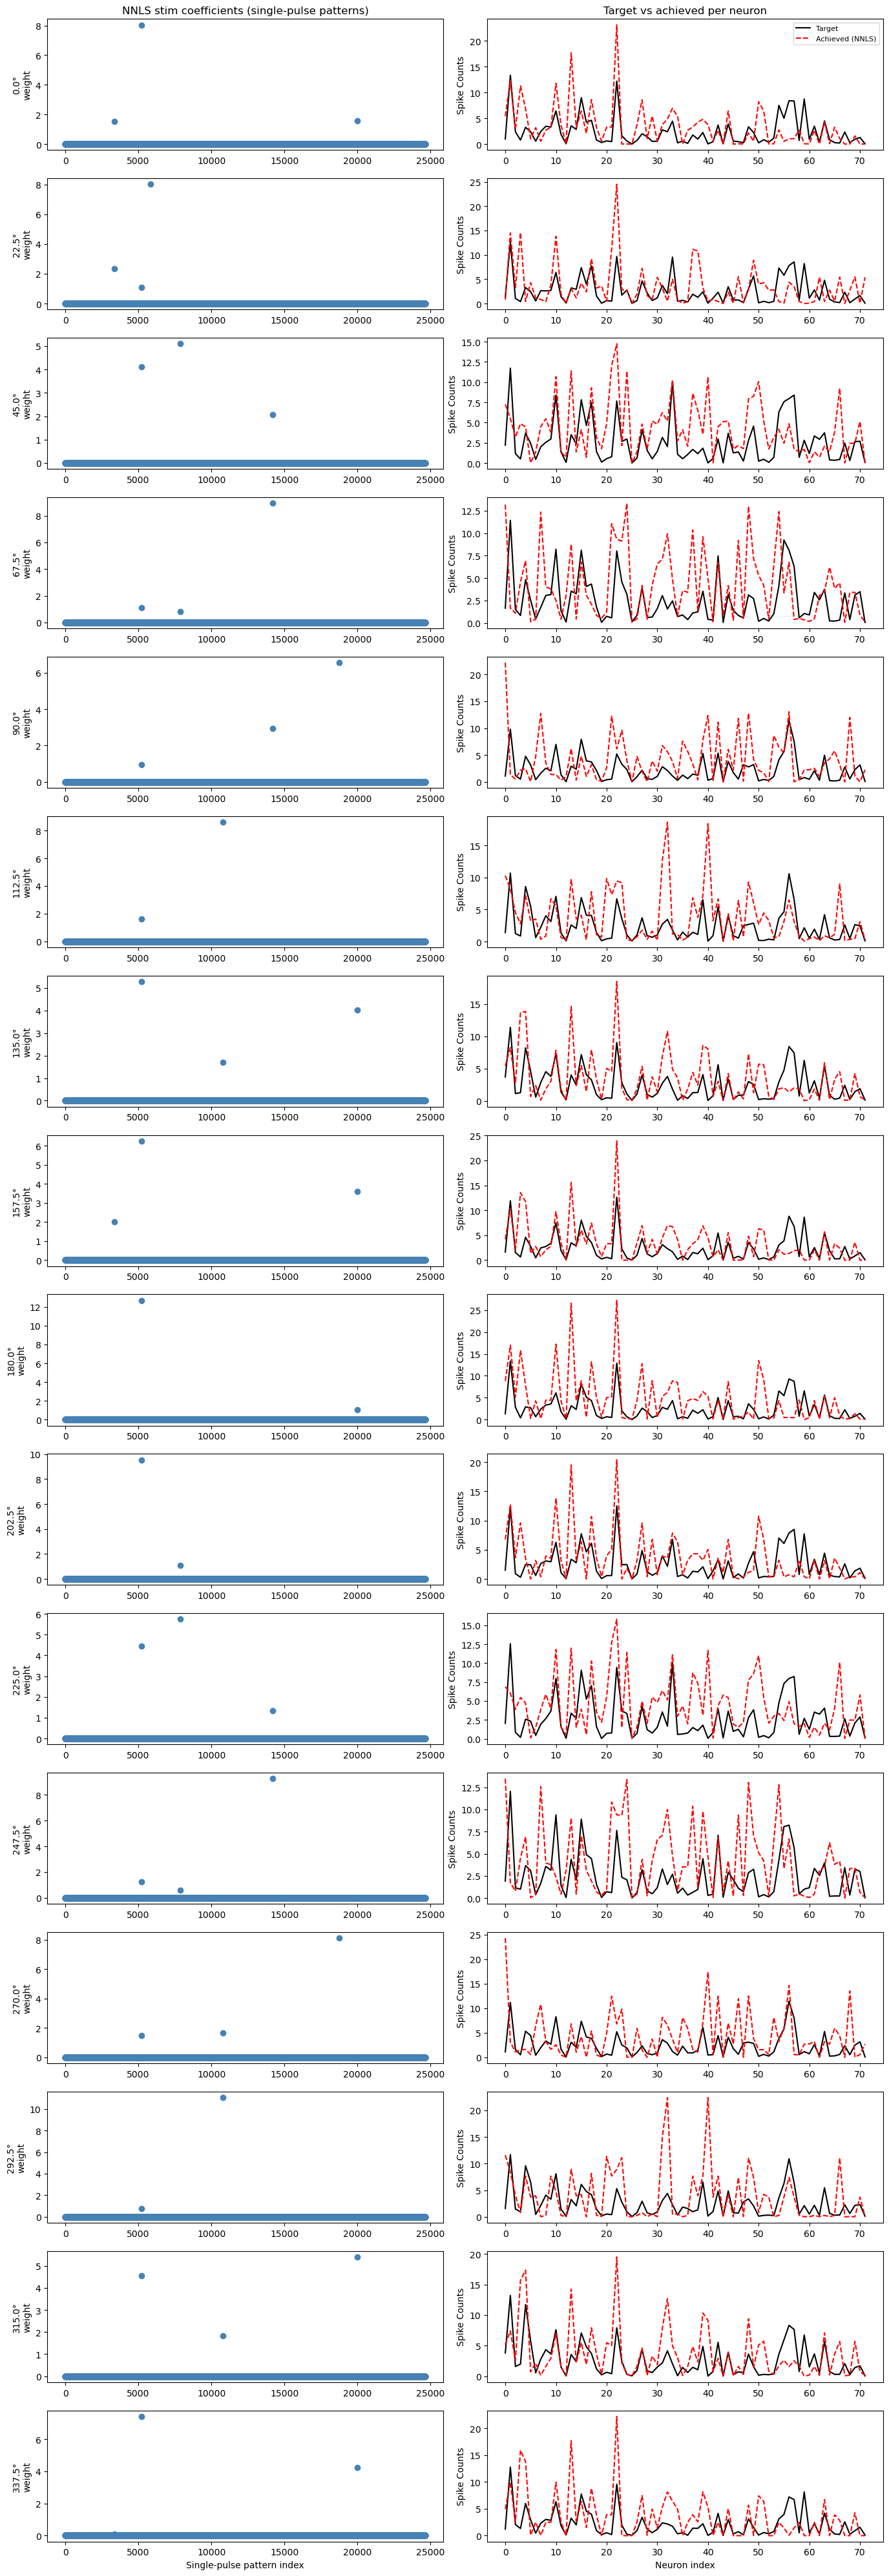

In [85]:
# Solve NNLS per orientation and collect weights + achieved vectors
all_weights, all_achieved = [], []
for i, ori in enumerate(orientations):
    target = target_vectors[i]
    w, err = controller.compute_stimulus(sta_matx.sum(axis=2),target, weight=proj.T, l1=0.1)
    all_weights.append(w)
    all_achieved.append(sta_matx.sum(axis=2) @ w)
all_weights  = np.array(all_weights)    # (n_orientations, n_single_pulse_patterns)
all_achieved = np.array(all_achieved)   # (n_orientations, n_neurons)

n_ori = len(orientations)
fig, axes = plt.subplots(n_ori, 2, figsize=(14, 2.5 * n_ori))
for i, ori in enumerate(orientations):
    # --- Stim weights (pattern index × weight) ---
    ax = axes[i, 0]
    bar_weights = all_weights
    bar_weights[bar_weights < 1e-4] = 0 # zero out hard to see bars 
    ax.scatter(np.arange(all_weights.shape[1]), bar_weights[i], color='steelblue')
    ax.set_ylabel(f'{ori:.1f}°\nweight')
    if i == 0:
        ax.set_title('NNLS stim coefficients (single-pulse patterns)')
    if i == n_ori - 1:
        ax.set_xlabel('Single-pulse pattern index')

    # --- Target vs achieved per neuron ---
    ax = axes[i, 1]
    x = np.arange(n_neurons)
    ax.plot(x, target_vectors[i], 'k-', lw=1.5, label='Target')
    ax.plot(x, all_achieved[i], 'r--', lw=1.5, label='Achieved (NNLS)')
    ax.set_ylabel('Spike Counts')
    if i == 0:
        ax.set_title('Target vs achieved per neuron')
        ax.legend(loc='upper right', fontsize=8)
    if i == n_ori - 1:
        ax.set_xlabel('Neuron index')

plt.tight_layout()
plt.savefig('results/viz/nnls_per_orientation.png', dpi=100)
plt.show()


In [136]:
# for each orientation, compute a stimulus input using the weights as 10 ms patterns. 
# interpret int(weights) as n times given pattern should be delivered
n_time_bins = 50
n_electrodes = len(list(model_col_sum.keys())[0])

ori_stim_inputs = []
for idx, ori in enumerate(orientations):
    print ("Orientation : ", ori)
    stim_input = np.zeros((n_electrodes, n_time_bins)) # electrodes x time
    w = all_weights[idx] # weights for stim
    w_int = w.round(0)
    print ("Pulses to be delivered: ", w_int.sum())
    top_k_patterns = np.argsort(w_int)[::-1] 

    stim_input = np.zeros((n_stim_channels, n_time_bins), dtype=np.float32)
    # greeedy pattern assignment
    pat_idx = 0
    ran_out_of_pattern_stims = w_int.max() < 1
    while pat_idx < n_time_bins and not ran_out_of_pattern_stims:  # at most n_time_bins pulses
        if w_int.max() < 1:
            ran_out_of_pattern_stims = True
            continue 
        selected_idx = np.argmax(w_int) 
        print ("patidx : ", pat_idx, selected_idx)
        selected_pattern = np.array(list(model_col_sum.keys())[selected_idx])
        channels = np.argwhere(selected_pattern != 0)
        amps = selected_pattern[channels]
        for chidx, channel in enumerate(channels):
            print (chidx, channel)
            stim_input[channel, pat_idx] = amps[chidx]    
        w_int[selected_idx] -= 1 # delivered this pattern once, so its weight goes down 1
        pat_idx += 1
    ori_stim_inputs.append(stim_input)
ori_stim_inputs = np.array(ori_stim_inputs)
ori_stim_inputs.shape
    

Orientation :  0.0
Pulses to be delivered:  12.0
patidx :  0 5208
0 [0]
1 [11]
2 [12]
3 [36]
patidx :  1 5208
0 [0]
1 [11]
2 [12]
3 [36]
patidx :  2 5208
0 [0]
1 [11]
2 [12]
3 [36]
patidx :  3 5208
0 [0]
1 [11]
2 [12]
3 [36]
patidx :  4 5208
0 [0]
1 [11]
2 [12]
3 [36]
patidx :  5 5208
0 [0]
1 [11]
2 [12]
3 [36]
patidx :  6 3353
0 [3]
1 [8]
2 [10]
3 [14]
4 [32]
patidx :  7 5208
0 [0]
1 [11]
2 [12]
3 [36]
patidx :  8 19980
0 [0]
1 [17]
2 [27]
3 [33]
4 [39]
patidx :  9 3353
0 [3]
1 [8]
2 [10]
3 [14]
4 [32]
patidx :  10 5208
0 [0]
1 [11]
2 [12]
3 [36]
patidx :  11 19980
0 [0]
1 [17]
2 [27]
3 [33]
4 [39]
Orientation :  22.5
Pulses to be delivered:  11.0
patidx :  0 5847
0 [9]
1 [22]
2 [28]
3 [33]
4 [36]
5 [37]
patidx :  1 5847
0 [9]
1 [22]
2 [28]
3 [33]
4 [36]
5 [37]
patidx :  2 5847
0 [9]
1 [22]
2 [28]
3 [33]
4 [36]
5 [37]
patidx :  3 5847
0 [9]
1 [22]
2 [28]
3 [33]
4 [36]
5 [37]
patidx :  4 5847
0 [9]
1 [22]
2 [28]
3 [33]
4 [36]
5 [37]
patidx :  5 5847
0 [9]
1 [22]
2 [28]
3 [33]
4 [36]
5 

(16, 40, 50)

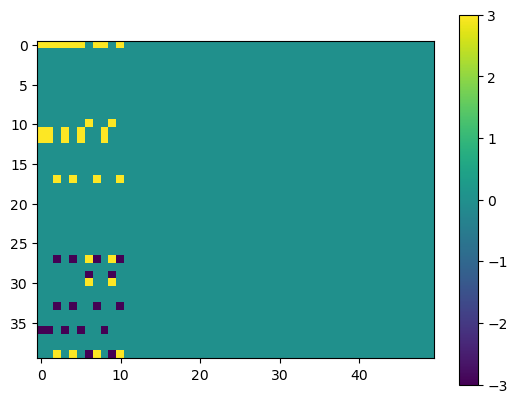

In [143]:
plt.imshow(ori_stim_inputs[6, :, :])
plt.colorbar()
plt.show()

In [ ]:
from models import sliding_window_predict_trial
n_output_bins_total = N_OUTPUT_BINS

# Per-neuron mean count per output bin — used as initial AR history
target_shape = (n_neurons, n_output_bins_total)
_accum, _n = np.zeros(target_shape, dtype=np.float64), 0
for sp in all_ds.spike_responses_binned.values():
    if sp.shape == target_shape:
        _accum += sp; _n += 1
per_neuron_mean = (_accum / max(_n, 1)).mean(axis=1, keepdims=True).astype(np.float32)
mean_binned = np.broadcast_to(per_neuron_mean, target_shape).copy()


cfg_fb = dict(
    n_input_bins=all_ds.n_input_bins,
    n_output_bins=all_ds.n_output_bins,
    output_bin_size_ms=all_ds.output_bin_size,
    input_bin_size_ms=all_ds.input_bin_size,
    max_time_ms=all_ds.max_time_ms,
    output_offset=all_ds.output_offset,
    history=all_ds.history or 0,
    init_state=all_ds.init_state,
)

stim_win_out_bins = (0, n_time_bins) # same as STA horizon
piggy_timing_idx = list(all_ds.spike_responses_binned.keys())[0]
model_tuple = (model, None, device)
feedback_loader = DataLoader(all_ds, batch_size=1, shuffle=False, num_workers=0)

achieved_ar = []
for stim in ori_stim_inputs:                              # (n_ch, n_input_bins_total)
    pred = sliding_window_predict_trial(
        model_tuple, cfg_fb, feedback_loader,
        timing_idx=piggy_timing_idx,
        stim_binned=stim.astype(np.float32),
        spikes_binned=mean_binned,                        # mean activity as initial history
    )                                                     # (n_neurons, n_output_bins_total)
    achieved_ar.append(pred[:, stim_win_out_bins[0]:stim_win_out_bins[1]].sum(axis=1))

achieved_ar = np.array(achieved_ar)                       # (n_ori, n_neurons)




In [153]:
import plotly.graph_objects as go

# Reuse the same projection basis
mean_vec = target_vectors.mean(axis=0)
pca_targets = PCA(n_components=2).fit(target_vectors)
proj, _ = np.linalg.qr(np.array([mean_vec, pca_targets.components_[0], pca_targets.components_[1]]).T)

target_proj  = target_vectors @ proj          # (n_ori, 3)
ar_proj      = achieved_ar @ proj             # (n_ori, 3)

doubled = (orientations * 2) % 360

fig = go.Figure()
fig.add_trace(go.Scatter3d(
    x=target_proj[:,0], y=target_proj[:,1], z=target_proj[:,2],
    mode='markers+text', name='Target (visual)',
    marker=dict(size=8, color=doubled, colorscale='HSV', cmin=0, cmax=360,
                colorbar=dict(title='Orientation (°)', tickvals=np.arange(0,361,72),
                              ticktext=[f'{int(v/2)}°' for v in np.arange(0,361,72)]),
                line=dict(color='black', width=1)),
    text=[f'{int(o)}°' for o in orientations], textposition='top center',
))
fig.add_trace(go.Scatter3d(
    x=ar_proj[:,0], y=ar_proj[:,1], z=ar_proj[:,2],
    mode='markers+text', name='NNLS+AR model',
    marker=dict(size=6, color=doubled, colorscale='HSV', cmin=0, cmax=360, symbol='diamond',
                line=dict(color='black', width=1)),
    text=[f'~{int(o)}°' for o in orientations], textposition='bottom center',
))
fig.update_layout(
    title='STA-NNLS: visual target vs AR model prediction',
    scene=dict(xaxis_title='CIS', yaxis_title='PC1', zaxis_title='PC2', aspectmode='data'),
    width=900, height=700,
)
fig.show()


10 10 800


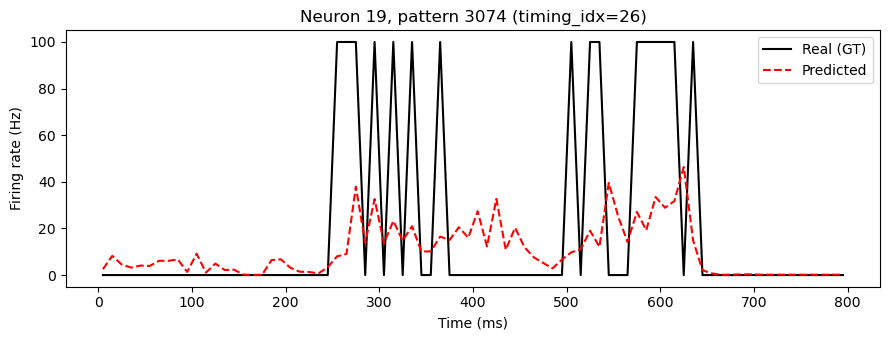

In [154]:
# Real vs. predicted firing rate for a single neuron on a single trial\n
from models import sliding_window_predict_trial
print (test_ds.output_bin_size, test_ds.input_bin_size, test_ds.max_time_ms)
NEURON_IDX   = 19                            # which neuron to plot\n
TIMING_IDX   = test_ds.trial_indices[10]       # which trial\n
cfg_one = dict(
    n_input_bins=test_ds.n_input_bins,
    n_output_bins=test_ds.n_output_bins,
    output_bin_size_ms=test_ds.output_bin_size,
    input_bin_size_ms=test_ds.input_bin_size,
    max_time_ms=test_ds.max_time_ms,
    output_offset=test_ds.output_offset,
    history=test_ds.history or 0,
    init_state=test_ds.init_state,
)
pred_rate = sliding_window_predict_trial(
    (model, None, device), cfg_one, test_loader, TIMING_IDX,
)  # (n_neurons, n_output_bins_total), mean spikes per output bin\n
gt_counts = test_ds.spike_responses_binned[TIMING_IDX]

out_bin_ms = test_ds.output_bin_size
pred_hz = pred_rate * (1000.0 / out_bin_ms)
gt_hz   = gt_counts * (1000.0 / out_bin_ms)

n_bins = pred_rate.shape[1]
t_ms   = (np.arange(n_bins) + 0.5) * out_bin_ms

fig, ax = plt.subplots(figsize=(9, 3.5))
ax.plot(t_ms, gt_hz[NEURON_IDX],   'k-',  lw=1.5, label='Real (GT)')
ax.plot(t_ms, pred_hz[NEURON_IDX], 'r--', lw=1.5, label='Predicted')
pname = test_ds.timing_to_pattern[TIMING_IDX]
ax.set_title(f'Neuron {NEURON_IDX}, pattern {pname} (timing_idx={TIMING_IDX})')
ax.set_xlabel('Time (ms)')
ax.set_ylabel('Firing rate (Hz)')
ax.legend()
plt.tight_layout()
plt.show()